# Lectura y descripción del dataset `cs_construccion`

En este notebook cargamos el fichero **`cs_construccion.csv`** y utilizamos **`DataDictionary.csv`** para conocer el significado de cada columna.

El conjunto de datos corresponde al problema de *credit scoring* **"Give Me Some Credit"**: cada fila es un solicitante de crédito y el objetivo es predecir si sufrirá una morosidad grave en los próximos 2 años (`SeriousDlqin2yrs`).

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import random
import shap
from sklearn.model_selection import train_test_split
from space_bandits import LinearBandits
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Lectura del dataset principal (separador por comas, con cabecera)
df = pd.read_csv("cs_construccion.csv")

print(f"Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas")
df.head()

Dimensiones del dataset: 105000 filas x 11 columnas


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0,0.090577,59,0,0.289273,7466.0,17,0,2,0,1.0
1,0,0.019327,74,0,1.505535,541.0,16,0,1,0,0.0
2,0,0.670039,34,0,0.081489,7816.0,9,0,0,0,0.0
3,0,1.000000,66,0,0.209132,6000.0,4,0,1,0,0.0
4,0,0.138060,65,1,100.000000,NaN,2,0,0,0,NaN


In [36]:
# Semilla global para reproducibilidad
# Fijamos una unica semilla que afecta a todas las fuentes de aleatoriedad del notebook:
#   - random (libreria estandar de Python)
#   - PYTHONHASHSEED (hashing de Python)
#   - np.random (estado global de NumPy; usado internamente por space_bandits.LinearBandits)
# Nota: los generadores locales (train_test_split(random_state=...), EntornoCredito(random_state=...)
# y np.random.default_rng(...)) ya usan SEED de forma explicita en sus celdas.

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

## Significado de cada columna (en español)

Descripción de cada variable de `cs_construccion.csv` según `DataDictionary.csv`, traducida al español:

| # | Columna | Significado | Tipo |
|---|---------|-------------|------|
| 0 | `SeriousDlqin2yrs` | **Variable objetivo:** la persona sufrió una morosidad grave (impago de 90 días o más) en los últimos 2 años. | Binaria (0/1) |
| 1 | `RevolvingUtilizationOfUnsecuredLines` | Saldo total en tarjetas de crédito y líneas de crédito personales (excluyendo inmuebles y préstamos a plazos como el del coche) dividido entre la suma de los límites de crédito. | Porcentaje |
| 2 | `age` | Edad del solicitante en años. | Entero |
| 3 | `NumberOfTime30-59DaysPastDueNotWorse` | Número de veces que el solicitante ha tenido entre 30 y 59 días de retraso en el pago (sin llegar a peor) en los últimos 2 años. | Entero |
| 4 | `DebtRatio` | Pagos mensuales de deuda, pensiones y gastos de manutención divididos entre los ingresos mensuales brutos. | Porcentaje |
| 5 | `MonthlyIncome` | Ingresos mensuales. | Real |
| 6 | `NumberOfOpenCreditLinesAndLoans` | Número de préstamos abiertos (a plazos, como el del coche o la hipoteca) y líneas de crédito (p. ej. tarjetas de crédito). | Entero |
| 7 | `NumberOfTimes90DaysLate` | Número de veces que el solicitante ha tenido 90 días o más de retraso en el pago. | Entero |
| 8 | `NumberRealEstateLoansOrLines` | Número de préstamos hipotecarios e inmobiliarios, incluyendo líneas de crédito con garantía hipotecaria. | Entero |
| 9 | `NumberOfTime60-89DaysPastDueNotWorse` | Número de veces que el solicitante ha tenido entre 60 y 89 días de retraso en el pago (sin llegar a peor) en los últimos 2 años. | Entero |
| 10 | `NumberOfDependents` | Número de personas a cargo en la familia, sin contarse a sí mismo (cónyuge, hijos, etc.). | Entero |

## Rango de valores de cada variable

Antes de modelar, revisamos el rango en el que se mueve cada variable (mínimo, máximo, cuartiles) y los valores ausentes. Esto permite detectar posibles anomalías y decidir qué habrá que limpiar o imputar.

In [37]:
# Estadísticos descriptivos: rango (min/max), cuartiles y media de cada variable
resumen = df.describe().T

# Añadimos el número y el porcentaje de valores ausentes por columna
resumen["nulos"] = df.isna().sum()
resumen["% nulos"] = (df.isna().mean() * 100).round(2)

resumen

,count,mean,std,min,25%,50%,75%,max,nulos,% nulos
SeriousDlqin2yrs,105000.0,0.066838,0.249743,0.0,0.000000,0.000000,0.000000,1.0,0,0.00
RevolvingUtilizationOfUnsecuredLines,105000.0,6.146972,217.681366,0.0,0.029939,0.154674,0.561067,22198.0,0,0.00
age,105000.0,52.221610,14.765680,0.0,41.000000,52.000000,63.000000,109.0,0,0.00
NumberOfTime30-59DaysPastDueNotWorse,105000.0,0.419933,4.188991,0.0,0.000000,0.000000,0.000000,98.0,0,0.00
DebtRatio,105000.0,354.160487,1999.455352,0.0,0.174872,0.366143,0.869178,329664.0,0,0.00
MonthlyIncome,84205.0,6700.439214,15368.210022,0.0,3400.000000,5400.000000,8250.000000,3008750.0,20795,19.80
NumberOfOpenCreditLinesAndLoans,105000.0,8.440276,5.130889,0.0,5.000000,8.000000,11.000000,58.0,0,0.00
NumberOfTimes90DaysLate,105000.0,0.265105,4.166023,0.0,0.000000,0.000000,0.000000,98.0,0,0.00
NumberRealEstateLoansOrLines,105000.0,1.016429,1.133977,0.0,0.000000,1.000000,2.000000,54.0,0,0.00
NumberOfTime60-89DaysPastDueNotWorse,105000.0,0.239286,4.151858,0.0,0.000000,0.000000,0.000000,98.0,0,0.00


In [38]:
# Comprobación del caso anómalo age = 0
n_age_cero = (df["age"] == 0).sum()
print(f"Número de solicitantes con age = 0: {n_age_cero}")

# Mostramos las filas afectadas
df[df["age"] == 0]

Número de solicitantes con age = 0: 1


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
89320,0,1.0,0,1,0.436927,6000.0,6,0,2,0,2.0


### Anomalías detectadas en los rangos

Observando los rangos aparecen varios problemas de calidad de datos que habrá que tratar antes de modelar:

| Variable | Qué se observa | Por qué es sospechoso |
|---|---|---|
| `age` | mínimo = **0** | Imposible para un solicitante de crédito (hay 1 caso). |
| `RevolvingUtilizationOfUnsecuredLines` | máximo ≈ **22.198** | Debería ser un ratio cercano a 0–1; hay valores extremos (*outliers*). |
| `DebtRatio` | máximo ≈ **329.664** | Ratio disparado; *outliers* muy alejados de la mediana. |
| `MonthlyIncome` | máximo ≈ **3.008.750** y **~20.795 nulos (≈20%)** | Valores extremos y una fracción importante de datos ausentes. |
| `NumberOfTime30-59DaysPastDueNotWorse`, `NumberOfTimes90DaysLate`, `NumberOfTime60-89DaysPastDueNotWorse` | máximo = **96 / 98** | Saltan bruscamente desde ~13; son **valores centinela** (códigos de "no disponible"), no cuentas reales. |
| `NumberOfDependents` | **~2.738 nulos** | Valores ausentes que habrá que imputar. |

**Conclusión:** antes de entrenar cualquier modelo será necesario (1) imputar los nulos de `MonthlyIncome` y `NumberOfDependents`, (2) tratar los *outliers* de los ratios y (3) decidir qué hacer con los valores centinela (96/98) de los contadores de morosidad y con la edad = 0.

## Limpieza de datos

### `age`: eliminación del registro con edad 0

Al tratarse de un único registro con un valor imposible (`age = 0`), lo eliminamos. Al ser una sola fila entre 105.000, no hay pérdida de información relevante ni impacto estadístico.

In [39]:
# Eliminamos la fila con age = 0
antes = len(df)
df = df[df["age"] > 0].reset_index(drop=True)
print(f"Filas eliminadas por age = 0: {antes - len(df)}")
print(f"Dimensiones tras la limpieza: {df.shape[0]} filas x {df.shape[1]} columnas")

Filas eliminadas por age = 0: 1
Dimensiones tras la limpieza: 104999 filas x 11 columnas


### Funciones auxiliares de limpieza

Varias operaciones de limpieza se repiten en más de una variable, así que las extraemos en funciones reutilizables para no duplicar código:

- `resumen_por_tramo_edad`: mediana, media y nº de casos de una variable por tramo de edad (sirve para justificar la relación con la edad).
- `imputar_por_tramo_edad`: crea la columna indicadora `{variable}_missing` e imputa los nulos con la mediana de su tramo de edad.
- `outliers_por_umbral`: para una lista de umbrales, resume cuántas filas los superan, qué porcentaje del total representan y su tasa de morosidad (con columnas extra opcionales), para decidir cómo tratar los *outliers*.

In [40]:
# Cortes de edad usados en toda la imputación por tramos
cortes = [0, 30, 40, 50, 60, 70, 150]


def resumen_por_tramo_edad(df, columna, cortes):
    """Mediana, media y nº de casos (no nulos) de `columna` por tramo de edad.

    Útil para comprobar/justificar si existe relación entre la edad y la variable.
    """
    sub = df.dropna(subset=[columna])
    grupo = sub.groupby(pd.cut(sub["age"], cortes), observed=True)[columna]
    return pd.concat(
        [grupo.median().rename("mediana"),
         grupo.mean().round(2).rename("media"),
         grupo.size().rename("n")],
        axis=1,
    )


def imputar_por_tramo_edad(df, columna, cortes, crear_flag=True):
    """Imputa los nulos de `columna` con la mediana de su tramo de edad (in place).

    Si `crear_flag` es True, añade primero la columna indicadora `{columna}_missing`
    (1 si el valor estaba ausente, 0 si no), ya que la propia ausencia puede ser informativa.
    """
    if crear_flag:
        df[f"{columna}_missing"] = df[columna].isna().astype(int)

    mediana_tramo = df.groupby(pd.cut(df["age"], cortes), observed=True)[columna].transform("median")
    n_antes = df[columna].isna().sum()
    df[columna] = df[columna].fillna(mediana_tramo)

    print(f"[{columna}] valores imputados: {n_antes} | nulos restantes: {df[columna].isna().sum()}")
    if crear_flag:
        print(f"[{columna}] individuos con {columna}_missing = 1: {df[f'{columna}_missing'].sum()}")


def outliers_por_umbral(df, columna, umbrales, objetivo="SeriousDlqin2yrs", cols_extra=None):
    """Resumen de outliers de `columna` para una lista de umbrales.

    Para cada umbral devuelve el nº de filas con valor > umbral, su % sobre el total y la
    tasa media de `objetivo` (morosidad) en ese grupo. `cols_extra` permite añadir el
    porcentaje medio de columnas binarias adicionales (p. ej. un flag de valor ausente).
    """
    cols_extra = cols_extra or []
    filas = []
    for umbral in umbrales:
        grupo = df[df[columna] > umbral]
        fila = {
            "umbral (>)": umbral,
            "n_filas": len(grupo),
            "% del total": round(len(grupo) / len(df) * 100, 2),
            "morosidad %": round(grupo[objetivo].mean() * 100, 2),
        }
        for c in cols_extra:
            fila[f"% {c}"] = round(grupo[c].mean() * 100, 1)
        filas.append(fila)
    return pd.DataFrame(filas).set_index("umbral (>)")

### `MonthlyIncome`: imputación por mediana según tramo de edad

`MonthlyIncome` tiene ~20% de valores ausentes, por lo que eliminar esas filas no es viable (perderíamos una quinta parte del dataset e introduciríamos sesgo). En su lugar, imputamos, pero antes justificamos **con qué** imputar.

En vez de una mediana global, buscamos una variable que se relacione con el ingreso para hacer una imputación condicional. La siguiente celda analiza dos cosas: la correlación lineal de `MonthlyIncome` con el resto de variables y su mediana por tramo de edad.

In [41]:
# --- Justificación de la variable de agrupación ---

# 1) Correlación lineal de MonthlyIncome con el resto (solo filas con ingreso conocido)
conocidos = df.dropna(subset=["MonthlyIncome"])
corr = (conocidos.corr(numeric_only=True)["MonthlyIncome"]
        .drop("MonthlyIncome")
        .sort_values(key=abs, ascending=False))
print("Correlación lineal de MonthlyIncome con el resto de variables:")
print(corr.round(3))

# 2) Mediana/media de MonthlyIncome por tramo de edad (usa la función auxiliar)
print("\nMonthlyIncome por tramo de edad:")
print(resumen_por_tramo_edad(df, "MonthlyIncome", cortes))
print(f"\nMediana global de MonthlyIncome: {df['MonthlyIncome'].median()}")

Correlación lineal de MonthlyIncome con el resto de variables:
NumberRealEstateLoansOrLines            0.119
NumberOfOpenCreditLinesAndLoans         0.085
NumberOfDependents                      0.063
age                                     0.033
DebtRatio                              -0.027
SeriousDlqin2yrs                       -0.018
NumberOfTimes90DaysLate                -0.012
NumberOfTime60-89DaysPastDueNotWorse   -0.010
NumberOfTime30-59DaysPastDueNotWorse   -0.009
RevolvingUtilizationOfUnsecuredLines    0.004
Name: MonthlyIncome, dtype: float64

MonthlyIncome por tramo de edad:
           mediana    media      n
age                               
(0, 30]     2800.0  3213.71   6373
(30, 40]    4950.0  5770.31  14893
(40, 50]    6083.0  7446.38  20650
(50, 60]    6307.0  7856.50  19459
(60, 70]    5833.0  7280.22  14375
(70, 150]   4500.0  5498.67   8454

Mediana global de MonthlyIncome: 5400.0


**Interpretación:** las correlaciones lineales son todas muy débiles (la mayor, ≈0,12, con `NumberRealEstateLoansOrLines`; `age` apenas 0,03). Sin embargo, la mediana por tramo de edad revela una relación clara en **U invertida**: el ingreso sube desde ~2.800 (menores de 30) hasta un pico de ~6.300 (50–60 años) y luego baja en la jubilación (~4.500). Esta relación no lineal la pierde la correlación de Pearson, pero es real y relevante (rango de 2.800 a 6.300 frente a la mediana global de 5.400).

Por tanto, **imputamos `MonthlyIncome` con la mediana de su tramo de edad**. Además, creamos la columna indicadora `MonthlyIncome_missing`: el hecho de no declarar ingresos puede ser informativo para predecir la morosidad, y conservar esa señal es prácticamente gratis.

In [42]:
# Imputación de MonthlyIncome por mediana de tramo de edad + columna indicadora MonthlyIncome_missing
imputar_por_tramo_edad(df, "MonthlyIncome", cortes)

[MonthlyIncome] valores imputados: 20795 | nulos restantes: 0
[MonthlyIncome] individuos con MonthlyIncome_missing = 1: 20795


### `NumberOfDependents`: imputación por mediana según tramo de edad

`NumberOfDependents` tiene ~2,6% de nulos. Aplicamos el mismo enfoque que en `MonthlyIncome`, bajo la hipótesis de que la edad también se relaciona con el número de personas a cargo. La siguiente celda lo comprueba con la función `resumen_por_tramo_edad`.

In [43]:
# Relación entre edad y número de dependientes (reutiliza la función auxiliar)
print("NumberOfDependents por tramo de edad:")
print(resumen_por_tramo_edad(df, "NumberOfDependents", cortes))
print(f"\nMediana global de NumberOfDependents: {df['NumberOfDependents'].median()}")

NumberOfDependents por tramo de edad:
           mediana  media      n
age                             
(0, 30]        0.0   0.33   7261
(30, 40]       1.0   1.01  17010
(40, 50]       1.0   1.28  24227
(50, 60]       0.0   0.78  23753
(60, 70]       0.0   0.34  18656
(70, 150]      0.0   0.16  11354

Mediana global de NumberOfDependents: 0.0


**Interpretación:** la **media** por tramo confirma la relación esperada en forma de U invertida (0,33 en menores de 30 → pico de 1,28 en los 40–50 → 0,16 en mayores de 70): tiene sentido, pocos dependientes de joven, máximo en la mediana edad y "nido vacío" al envejecer. Ahora bien, la variable está muy concentrada en 0 (≈58% de los casos), por lo que la **mediana** solo distingue el tramo 30–50 (mediana 1) del resto (mediana 0); la señal es real pero modesta.

Aun así, imputamos con la **mediana del tramo de edad** por coherencia con `MonthlyIncome` (mejora ligeramente la mediana global, que sería 0 para todos) y, como solo hay un ~2,6% de nulos, la decisión apenas afecta al dataset. También añadimos la columna indicadora `NumberOfDependents_missing`.

In [44]:
# Imputación de NumberOfDependents por mediana de tramo de edad + columna indicadora NumberOfDependents_missing
imputar_por_tramo_edad(df, "NumberOfDependents", cortes)

[NumberOfDependents] valores imputados: 2738 | nulos restantes: 0
[NumberOfDependents] individuos con NumberOfDependents_missing = 1: 2738


### `RevolvingUtilizationOfUnsecuredLines`: winsorización de la cola extrema

Esta variable es un ratio de utilización del crédito (saldo / límite), que debería moverse en torno a 0–1, aunque valores algo por encima de 1 son legítimos (personas que superan su límite). El análisis de outliers muestra dos realidades distintas:

- **Valores entre 1 y ~2:** no son errores, sino la señal más predictiva del dataset (morosidad del 25–37% frente al 6,7% global). **Se conservan.**
- **Cola extrema (> 10, hasta 22.198):** valores imposibles para un ratio, y con una morosidad (~6,8%) igual a la tasa base, es decir, sin valor predictivo. Son ~176 filas (0,17%) claramente corruptas.

En lugar de eliminar esas filas (perderíamos también su información en el resto de columnas), las **winsorizamos**: recortamos el valor a un tope de 10, conservando la fila.

In [45]:
# Análisis de outliers: nº de casos y tasa de morosidad por umbral (usa la función auxiliar)
print(f"Tasa de morosidad global: {df['SeriousDlqin2yrs'].mean():.2%}  (n={len(df)})\n")
print(outliers_por_umbral(df, "RevolvingUtilizationOfUnsecuredLines", [1, 1.5, 2, 5, 10, 13]))

Tasa de morosidad global: 6.68%  (n=104999)

            n_filas  % del total  morosidad %
umbral (>)                                   
1.0            2383         2.27        37.05
1.5             433         0.41        25.40
2.0             261         0.25        13.03
5.0             184         0.18         7.61
10.0            176         0.17         6.82
13.0            174         0.17         5.75


In [46]:
# Winsorización: recortamos los valores > 10 al tope de 10 (conservando la fila)
TOPE_REVOLVING = 10
col = "RevolvingUtilizationOfUnsecuredLines"

n_afectados = (df[col] > TOPE_REVOLVING).sum()
df[col] = df[col].clip(upper=TOPE_REVOLVING)

print(f"Valores recortados en {col}: {n_afectados}")
print(f"Nuevo máximo de {col}: {df[col].max()}")

Valores recortados en RevolvingUtilizationOfUnsecuredLines: 176
Nuevo máximo de RevolvingUtilizationOfUnsecuredLines: 10.0


### `DebtRatio`: winsorización de la cola extrema

`DebtRatio` es el ratio deuda/ingreso, que debería moverse en torno a 0–1 (mediana 0,37, Q3 0,87). Sin embargo, a partir del percentil 90 los valores saltan a miles, hasta un máximo de ~329.664, imposible para un ratio. La siguiente celda analiza los outliers reutilizando `outliers_por_umbral`, añadiendo como columna extra el flag `MonthlyIncome_missing` para ver su relación con la ausencia de ingreso.

In [47]:
# Análisis de outliers de DebtRatio, incluyendo su relación con el ingreso ausente
print(f"Tasa de morosidad global: {df['SeriousDlqin2yrs'].mean():.2%}  (n={len(df)})\n")
print(outliers_por_umbral(df, "DebtRatio", [1, 2, 5, 100, 1000], cols_extra=["MonthlyIncome_missing"]))

Tasa de morosidad global: 6.68%  (n=104999)

            n_filas  % del total  morosidad %  % MonthlyIncome_missing
umbral (>)                                                            
1             24594        23.42         6.48                     79.4
2             21712        20.68         5.55                     89.5
5             20708        19.72         5.47                     92.1
100           17054        16.24         5.66                     93.1
1000          11884        11.32         4.84                     94.2


**Interpretación:** a diferencia de `RevolvingUtilizationOfUnsecuredLines`, aquí la cola extrema **no es una fracción diminuta** (los valores `> 100` son ~16% del dataset) y **no concentra morosidad** (tasa ≈ o por debajo de la global). Su origen es estructural: como `DebtRatio = deuda / ingreso`, cuando el ingreso es 0 o ausente el ratio explota. Lo confirma el flag: entre los valores `> 2`, el ~90% corresponde a individuos con ingreso ausente (`MonthlyIncome_missing = 1`), información que ya conservamos.

**Winsorizamos** `DebtRatio` al **percentil 95** (≈2.465), recortando solo el ~5% superior y conservando la fila. Es una decisión conservadora: elimina las magnitudes más extremas (hasta ~329.664) con un impacto pequeño en el dataset. Como contrapartida honesta, deja valores todavía implausibles para un ratio (cientos/miles); si se quisiera un criterio más estricto se podría bajar el tope, pero la señal de "sin ingreso" que explica estos casos ya está preservada en `MonthlyIncome_missing`.

In [48]:
# Winsorización: recortamos DebtRatio al percentil 95 (conservando la fila)
col = "DebtRatio"
tope_debtratio = df[col].quantile(0.95)

n_afectados = (df[col] > tope_debtratio).sum()
df[col] = df[col].clip(upper=tope_debtratio)

print(f"Tope (percentil 95) de {col}: {tope_debtratio:.2f}")
print(f"Valores recortados en {col}: {n_afectados} ({n_afectados / len(df):.2%})")
print(f"Nuevo máximo de {col}: {df[col].max()}")

Tope (percentil 95) de DebtRatio: 2465.00
Valores recortados en DebtRatio: 5248 (5.00%)
Nuevo máximo de DebtRatio: 2465.0


### Contadores de morosidad: valores centinela 96/98

Los tres contadores de retrasos en el pago (`NumberOfTime30-59DaysPastDueNotWorse`, `NumberOfTimes90DaysLate`, `NumberOfTime60-89DaysPastDueNotWorse`) contienen los valores **96 y 98**, que no son cuentas reales sino **valores centinela** (códigos reservados para "no disponible"): retrasarse 98 veces en 2 años es imposible, hay un salto brusco desde los valores reales (~8-15) y los códigos aparecen en las mismas filas de las tres columnas a la vez. La siguiente celda lo evidencia.

In [49]:
# --- Evidencia de los valores centinela ---
CENTINELAS = [96, 98]
cols_morosidad = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate",
    "NumberOfTime60-89DaysPastDueNotWorse",
]

# Valores presentes en cada contador (se ve el salto: ...->96, 98)
print("Valores presentes en cada contador:")
for c in cols_morosidad:
    print(f"  {c}: {sorted(int(v) for v in df[c].unique())}")

# Filas afectadas y su morosidad frente a la global
centinela_mask = df[cols_morosidad].isin(CENTINELAS).any(axis=1)
print(f"\nFilas con valor centinela (96/98): {centinela_mask.sum()}")
print(f"Morosidad en esas filas: {df.loc[centinela_mask, 'SeriousDlqin2yrs'].mean():.2%}"
      f"  (global: {df['SeriousDlqin2yrs'].mean():.2%})")

Valores presentes en cada contador:
  NumberOfTime30-59DaysPastDueNotWorse: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 96, 98]
  NumberOfTimes90DaysLate: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 96, 98]
  NumberOfTime60-89DaysPastDueNotWorse: [0, 1, 2, 3, 4, 5, 6, 7, 8, 96, 98]

Filas con valor centinela (96/98): 188
Morosidad en esas filas: 54.26%  (global: 6.68%)


**Decisión:** las 188 filas con centinela tienen una morosidad del **54,26%**, ocho veces la global (6,68%), así que la propia presencia del código es muy informativa. Por eso aplicamos lo siguiente:

1. **Flag compartido** `PastDue_centinela` (las 188 filas coinciden en las tres columnas): conserva la señal de "este registro tenía valores no disponibles", que resultó estar asociada a alta morosidad.
2. **Sustituir cada 96/98 por el máximo legítimo observado en su propia columna** (12, 15 y 8 respectivamente). La justificación es precisamente esa alta morosidad: estos casos se comportan como los deudores más problemáticos, por lo que mapearlos al valor real más alto de la escala es coherente con su riesgo, sin introducir un número imposible (98) que distorsionaría escalas y correlaciones.

In [50]:
# 1) Flag compartido: 1 si la fila tiene un valor centinela en algún contador de morosidad
df["PastDue_centinela"] = df[cols_morosidad].isin(CENTINELAS).any(axis=1).astype(int)

# 2) Sustituir cada centinela por el máximo legítimo de su propia columna
for c in cols_morosidad:
    max_legit = df.loc[~df[c].isin(CENTINELAS), c].max()
    n_cent = df[c].isin(CENTINELAS).sum()
    df.loc[df[c].isin(CENTINELAS), c] = max_legit
    print(f"[{c}] {n_cent} centinelas sustituidos por {max_legit} (máx. legítimo) | nuevo máx.: {df[c].max()}")

print(f"\nFilas marcadas con PastDue_centinela = 1: {df['PastDue_centinela'].sum()}")

[NumberOfTime30-59DaysPastDueNotWorse] 188 centinelas sustituidos por 12 (máx. legítimo) | nuevo máx.: 12
[NumberOfTimes90DaysLate] 188 centinelas sustituidos por 15 (máx. legítimo) | nuevo máx.: 15
[NumberOfTime60-89DaysPastDueNotWorse] 188 centinelas sustituidos por 8 (máx. legítimo) | nuevo máx.: 8

Filas marcadas con PastDue_centinela = 1: 188


## Verificación final del dataset limpio

Comprobamos que, tras toda la limpieza, el `df` está listo para modelar: sin valores ausentes, con los rangos ya saneados y con las nuevas columnas indicadoras añadidas.

In [51]:
# Comprobaciones automáticas del dataset limpio
print(f"Dimensiones finales: {df.shape[0]} filas x {df.shape[1]} columnas")

total_nulos = df.isna().sum().sum()
print(f"Total de valores ausentes: {total_nulos}")
assert total_nulos == 0, "Todavía quedan valores nulos en el dataset"

nuevas_columnas = ["MonthlyIncome_missing", "NumberOfDependents_missing", "PastDue_centinela"]
print(f"Nuevas columnas indicadoras presentes: {[c for c in nuevas_columnas if c in df.columns]}")

# Comprobamos que los contadores de morosidad ya no contienen los centinelas 96/98
sin_centinelas = not df[cols_morosidad].isin(CENTINELAS).any().any()
print(f"Contadores de morosidad sin valores centinela (96/98): {sin_centinelas}")
assert sin_centinelas, "Aún quedan valores centinela en los contadores de morosidad"

print("\nRango (min/max) y nulos de cada variable tras la limpieza:")
verificacion = df.describe().T[["min", "max"]]
verificacion["nulos"] = df.isna().sum()
verificacion

Dimensiones finales: 104999 filas x 14 columnas
Total de valores ausentes: 0
Nuevas columnas indicadoras presentes: ['MonthlyIncome_missing', 'NumberOfDependents_missing', 'PastDue_centinela']
Contadores de morosidad sin valores centinela (96/98): True

Rango (min/max) y nulos de cada variable tras la limpieza:


,min,max,nulos
SeriousDlqin2yrs,0.0,1.0,0
RevolvingUtilizationOfUnsecuredLines,0.0,10.0,0
age,21.0,109.0,0
NumberOfTime30-59DaysPastDueNotWorse,0.0,12.0,0
DebtRatio,0.0,2465.0,0
MonthlyIncome,0.0,3008750.0,0
NumberOfOpenCreditLinesAndLoans,0.0,58.0,0
NumberOfTimes90DaysLate,0.0,15.0,0
NumberRealEstateLoansOrLines,0.0,54.0,0
NumberOfTime60-89DaysPastDueNotWorse,0.0,8.0,0


## Preparación para el modelado: limpieza sin *data leakage*

El EDA anterior nos sirvió para **descubrir y justificar** el tratamiento de cada variable sobre el dataset completo. Sin embargo, de cara al modelado hay que aplicar esa limpieza con rigor para no filtrar información del conjunto de test (*data leakage*): todos los parámetros que se *aprenden* de los datos (medianas por tramo de edad, percentil 95 de `DebtRatio`, máximo legítimo de los contadores) deben calcularse **solo con `train`** y luego aplicarse tanto a `train` como a `test`.

Para ello encapsulamos la limpieza en una clase con patrón **fit / transform** (estilo scikit-learn): `fit` aprende los parámetros con `train` y `transform` los aplica a cualquier conjunto con esos mismos valores. Partimos de los datos **crudos** (recargados del CSV) para reproducir el proceso completo sin contaminación.

Nota sobre `age = 0`: al ser un único registro imposible, lo eliminamos como filtro de validez sobre los datos crudos antes de partir (no es un parámetro aprendido).

In [52]:

# Datos crudos (el df anterior ya está limpio; aquí reproducimos el proceso desde cero)
datos = pd.read_csv("cs_construccion.csv")

# Filtro de validez: eliminamos el registro imposible age = 0
datos = datos[datos["age"] > 0].reset_index(drop=True)

# Separamos predictoras (X) y objetivo (y)
X = datos.drop(columns="SeriousDlqin2yrs")
y = datos["SeriousDlqin2yrs"]

# Partición train/test estratificada (la clase positiva es minoritaria, ~6,7%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

print(f"Train: {X_train.shape[0]} filas | Test: {X_test.shape[0]} filas")
print(f"Morosidad train: {y_train.mean():.2%} | test: {y_test.mean():.2%}")

Train: 83999 filas | Test: 21000 filas
Morosidad train: 6.68% | test: 6.69%


El siguiente gráfico evidencia el fuerte **desbalanceo de clases** que motiva la partición estratificada: la clase positiva (morosidad grave) es minoritaria (~6,7%).

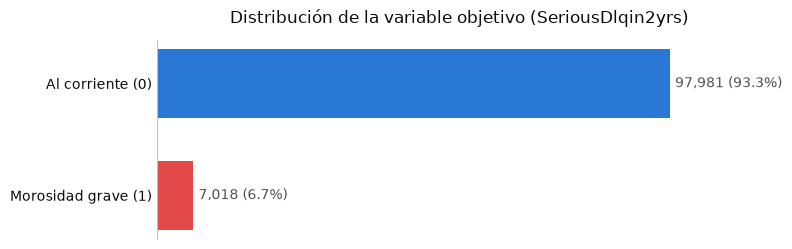

In [53]:
# Distribución de la variable objetivo (sobre el conjunto completo)
conteo = y.value_counts().sort_index()
prop = y.value_counts(normalize=True).sort_index()
etiquetas = ["Al corriente (0)", "Morosidad grave (1)"]
colores = ["#2a78d6", "#e34948"]  # azul (mayoría) / rojo (minoría)

fig, ax = plt.subplots(figsize=(8, 2.6))
barras = ax.barh(etiquetas, conteo.values, color=colores, height=0.62)

# Etiquetas directas: recuento y porcentaje al final de cada barra
for barra, n, p in zip(barras, conteo.values, prop.values):
    ax.text(n + max(conteo.values) * 0.01, barra.get_y() + barra.get_height() / 2,
            f"{n:,} ({p:.1%})", va="center", ha="left", fontsize=10, color="#52514e")

# Cromo recesivo: sin rejilla ni eje X (los valores están en las etiquetas)
ax.set_xlim(0, max(conteo.values) * 1.18)
ax.set_title("Distribución de la variable objetivo (SeriousDlqin2yrs)", fontsize=12, color="#0b0b0b", pad=12)
for s in ["top", "right", "bottom"]:
    ax.spines[s].set_visible(False)
ax.spines["left"].set_color("#c3c2b7")
ax.tick_params(axis="y", length=0, labelsize=10, colors="#0b0b0b")
ax.set_xticks([])
ax.invert_yaxis()  # clase 0 arriba
plt.tight_layout()
plt.show()

La clase `LimpiadorCreditScoring` consolida, en forma segura ante *leakage*, exactamente las mismas decisiones de limpieza que tomamos en el EDA:

- **`fit(X_train)`** aprende: medianas por tramo de edad de `MonthlyIncome` y `NumberOfDependents`, el percentil 95 de `DebtRatio` y el máximo legítimo de cada contador de morosidad.
- **`transform(X)`** aplica esos parámetros a cualquier conjunto: imputa con las medianas aprendidas (+ flags `_missing`), winsoriza `Revolving` a 10 y `DebtRatio` al p95 de train, y sustituye los centinelas 96/98 por el máximo legítimo de train (+ flag `PastDue_centinela`).

In [54]:
class LimpiadorCreditScoring:
    """Limpieza del dataset con patrón fit/transform para evitar data leakage.

    Aprende todos los parámetros que dependen de los datos usando SOLO el conjunto de
    entrenamiento (`fit`) y los aplica a cualquier conjunto (`transform`).
    """

    def __init__(self, cortes, centinelas=(96, 98)):
        self.cortes = cortes
        self.centinelas = list(centinelas)
        self.cols_morosidad = [
            "NumberOfTime30-59DaysPastDueNotWorse",
            "NumberOfTimes90DaysLate",
            "NumberOfTime60-89DaysPastDueNotWorse",
        ]

    def fit(self, X):
        tramo = pd.cut(X["age"], self.cortes)
        # Medianas por tramo de edad (y mediana global como respaldo) para imputar
        self.medianas_, self.mediana_global_ = {}, {}
        for col in ["MonthlyIncome", "NumberOfDependents"]:
            self.medianas_[col] = X.groupby(tramo, observed=True)[col].median()
            self.mediana_global_[col] = X[col].median()
        # Topes de winsorización
        self.tope_revolving_ = 10  # constante (no se aprende de los datos)
        self.tope_debtratio_ = X["DebtRatio"].quantile(0.95)
        # Máximo legítimo de cada contador (excluyendo los centinelas)
        self.max_legit_ = {
            c: int(X.loc[~X[c].isin(self.centinelas), c].max()) for c in self.cols_morosidad
        }
        return self

    def transform(self, X):
        X = X.copy()
        tramo = pd.cut(X["age"], self.cortes)

        # Imputación por mediana de tramo aprendida + flag de valor ausente
        for col in ["MonthlyIncome", "NumberOfDependents"]:
            X[f"{col}_missing"] = X[col].isna().astype(int)
            relleno = tramo.map(self.medianas_[col].to_dict()).astype(float)
            X[col] = X[col].fillna(relleno).fillna(self.mediana_global_[col])

        # Winsorización con los topes aprendidos en train
        X["RevolvingUtilizationOfUnsecuredLines"] = X["RevolvingUtilizationOfUnsecuredLines"].clip(upper=self.tope_revolving_)
        X["DebtRatio"] = X["DebtRatio"].clip(upper=self.tope_debtratio_)

        # Valores centinela: flag compartido + sustitución por el máximo legítimo de train
        X["PastDue_centinela"] = X[self.cols_morosidad].isin(self.centinelas).any(axis=1).astype(int)
        for c in self.cols_morosidad:
            X.loc[X[c].isin(self.centinelas), c] = self.max_legit_[c]

        return X

In [55]:
# Aprendemos los parámetros SOLO con train y transformamos ambos conjuntos
limpiador = LimpiadorCreditScoring(cortes).fit(X_train)
X_train_limpio = limpiador.transform(X_train)
X_test_limpio = limpiador.transform(X_test)

# Parámetros aprendidos en train
print("Parámetros aprendidos (solo train):")
print(f"  Tope DebtRatio (p95): {limpiador.tope_debtratio_:.2f}")
print(f"  Máx. legítimo contadores: {limpiador.max_legit_}")

# Verificación de ausencia de nulos y de centinelas en ambos conjuntos
for nombre, Xc in [("train", X_train_limpio), ("test", X_test_limpio)]:
    nulos = int(Xc.isna().sum().sum())
    quedan_cent = bool(Xc[limpiador.cols_morosidad].isin(limpiador.centinelas).any().any())
    print(f"\n{nombre}: {Xc.shape[0]} filas x {Xc.shape[1]} columnas | nulos: {nulos} | quedan centinelas: {quedan_cent}")
    assert nulos == 0 and not quedan_cent

print("\nEl tope de DebtRatio y demás parámetros provienen solo de train: no hay data leakage.")

Parámetros aprendidos (solo train):
  Tope DebtRatio (p95): 2466.00
  Máx. legítimo contadores: {'NumberOfTime30-59DaysPastDueNotWorse': 12, 'NumberOfTimes90DaysLate': 15, 'NumberOfTime60-89DaysPastDueNotWorse': 8}

train: 83999 filas x 13 columnas | nulos: 0 | quedan centinelas: False

test: 21000 filas x 13 columnas | nulos: 0 | quedan centinelas: False

El tope de DebtRatio y demás parámetros provienen solo de train: no hay data leakage.


## Entorno de decisión: bandit contextual coste-sensible

Antes de entrenar el bandit necesitamos un **entorno** que simule la llegada de solicitantes de crédito. En cada paso, el entorno expone el **contexto** (las variables del cliente) y, dada una **acción** (la predicción del modelo), devuelve un **refuerzo** definido por una **matriz de coste que elegimos nosotros**.

La idea clave frente a un clasificador clásico + umbral es que **el coste va dentro del refuerzo**: el bandit aprende directamente la política coste-óptima, sin ajustar ningún umbral a posteriori.

**Acciones** (problema binario, dos brazos):

| Acción | Significado | Predicción equivalente |
|:---:|:---|:---|
| `0` | conceder crédito | "al corriente" (clase 0) |
| `1` | denegar crédito | "moroso" (clase 1) |

**Matriz de refuerzo** (recompensa; negativo = coste). Tomando como *positivo* el evento "moroso":

| | Real: al corriente (0) | Real: moroso (1) |
|:---|:---:|:---:|
| **Conceder (0)** | TN → `+beneficio_TN` | **FN** → `-coste_FN` (se presta a un moroso) |
| **Denegar (1)** | **FP** → `-coste_FP` (se pierde un buen cliente) | TP → `+beneficio_TP` |

Por defecto los aciertos valen `0` y solo penalizamos los errores (coste-minimización pura), pero dejamos `beneficio_TN`/`beneficio_TP` como parámetros por si se quiere modelar el interés ganado en un crédito bien concedido. Normalmente `coste_FN` ≫ `coste_FP`: prestar a un moroso cuesta el principal, mientras que rechazar a un buen cliente solo cuesta el interés no ganado.

In [56]:
class EntornoCredito:
    """Entorno de decisión crediticia para un bandit contextual coste-sensible.

    Simula la llegada de solicitantes de crédito. En cada paso expone el contexto
    (variables del cliente) y, dada una acción (la predicción del modelo), devuelve un
    refuerzo definido por una matriz de coste que elige el usuario. Al meter el coste
    dentro del refuerzo, el bandit aprende directamente la política coste-óptima, sin
    ajustar ningún umbral a posteriori.

    Acciones:
        0 = conceder crédito  (predecir "al corriente")
        1 = denegar crédito   (predecir "moroso")

    Refuerzo (recompensa; negativo = coste) según (acción, etiqueta real):
        (0, 0) conceder a cliente sano  -> +beneficio_TN  (verdadero negativo)
        (0, 1) conceder a moroso        -> -coste_FN      (falso negativo)
        (1, 0) denegar a cliente sano   -> -coste_FP      (falso positivo)
        (1, 1) denegar a moroso         -> +beneficio_TP  (verdadero positivo)
    """

    N_ACCIONES = 2  # problema binario: dos brazos

    def __init__(self, X, y, coste_FP, coste_FN,
                 beneficio_TN=0.0, beneficio_TP=0.0, random_state=None):
        """
        X: DataFrame o array (n_muestras, n_features) con las variables de cada cliente.
        y: Series o array (n_muestras,) con la etiqueta real (0 = al corriente, 1 = moroso).
        coste_FP: coste (>= 0) de denegar crédito a un cliente que habría pagado.
        coste_FN: coste (>= 0) de conceder crédito a un cliente que resultará moroso.
        beneficio_TN / beneficio_TP: recompensa (>= 0) de los aciertos (por defecto 0,
            coste-minimización pura; súbelos para modelar el interés de un buen crédito).
        random_state: semilla para reproducir la secuencia de clientes.
        """
        self._X = np.asarray(X, dtype=float)
        self._y = np.asarray(y, dtype=int)
        if len(self._X) != len(self._y):
            raise ValueError("X e y deben tener el mismo número de filas.")

        self.columnas = list(X.columns) if hasattr(X, "columns") else None
        self.coste_FP = coste_FP
        self.coste_FN = coste_FN
        self.beneficio_TN = beneficio_TN
        self.beneficio_TP = beneficio_TP

        # Matriz de refuerzo indexada como matriz_recompensa[accion, etiqueta_real]
        self.matriz_recompensa = np.array([
            [beneficio_TN, -coste_FN],     # acción 0 (conceder): [real 0, real 1]
            [-coste_FP,    beneficio_TP],  # acción 1 (denegar):  [real 0, real 1]
        ], dtype=float)

        self._rng = np.random.default_rng(random_state)
        self.i = None  # índice del cliente actual (aún no hay ninguno)

    @property
    def n_features(self):
        """Número de variables del contexto."""
        return self._X.shape[1]

    def nuevo_cliente(self):
        """Selecciona un cliente al azar y devuelve su contexto (vector de features)."""
        self.i = int(self._rng.integers(len(self._X)))
        return self.contexto()

    def contexto(self):
        """Contexto (features) del cliente actual, como vector 1-D."""
        if self.i is None:
            raise RuntimeError("Llama antes a nuevo_cliente().")
        return self._X[self.i]

    def etiqueta_real(self):
        """Etiqueta real del cliente actual (0 = al corriente, 1 = moroso)."""
        if self.i is None:
            raise RuntimeError("Llama antes a nuevo_cliente().")
        return int(self._y[self.i])

    def act(self, accion):
        """Aplica la acción sobre el cliente actual y devuelve el refuerzo.

        accion: 0 = conceder crédito, 1 = denegar crédito.
        """
        if accion not in (0, 1):
            raise ValueError("accion debe ser 0 (conceder) o 1 (denegar).")
        return float(self.matriz_recompensa[accion, self.etiqueta_real()])

    def __repr__(self):
        return (f"EntornoCredito(n={len(self._X)}, coste_FP={self.coste_FP}, "
                f"coste_FN={self.coste_FN})")

In [57]:
# Comprobación rápida: los cuatro casos de la matriz de coste
entorno_train = EntornoCredito(X_train_limpio, y_train, coste_FP=1, coste_FN=10, random_state=SEED)
entorno_test = EntornoCredito(X_test_limpio, y_test, coste_FP=1, coste_FN=10, random_state=SEED)

print("Matriz de recompensa [accion, etiqueta_real]:")
print(entorno_train.matriz_recompensa)

# Verificamos que cada (accion, etiqueta_real) devuelve el refuerzo esperado
casos = {
    (0, 0): 0.0,    # conceder a cliente sano  -> TN
    (0, 1): -10.0,  # conceder a moroso        -> FN (coste alto)
    (1, 0): -1.0,   # denegar a cliente sano   -> FP (coste de oportunidad)
    (1, 1): 0.0,    # denegar a moroso         -> TP
}
for (accion, real), esperado in casos.items():
    assert entorno_train.matriz_recompensa[accion, real] == esperado
print("\nLos cuatro casos de coste se resuelven correctamente.")

# El contexto tiene la dimensión esperada (nº de features del dataset limpio)
contexto = entorno_train.nuevo_cliente()
print(f"Dimensión del contexto: {contexto.shape[0]} features "
      f"(coincide con X_train_limpio: {entorno_train.n_features == X_train_limpio.shape[1]})")

Matriz de recompensa [accion, etiqueta_real]:
[[  0. -10.]
 [ -1.   0.]]

Los cuatro casos de coste se resuelven correctamente.
Dimensión del contexto: 13 features (coincide con X_train_limpio: True)


## Política entrenada (offline full-information) y evaluada en test

Encapsulamos el pipeline en la clase `BanditCosteSensible` y entrenamos **un bandit por escenario de coste** (definidos en `ESCENARIOS`) para comparar cómo la matriz de coste moldea la política:

- **asimétrico (FP=1, FN=10):** un falso negativo (moroso aceptado) cuesta 10× un falso positivo → el bandit deniega de forma agresiva para no dejar pasar morosos.
- **simétrico (FP=1, FN=1):** ambos errores cuestan lo mismo → como la clase morosa es minoritaria (~6,7%), casi siempre sale a cuenta conceder, y el bandit apenas deniega.

Todas las celdas siguientes (evaluación, predicción a producción, SHAP, árbol surrogado y recourse) recorren el mismo diccionario `bandits`, **sin duplicar código**: añadir un escenario nuevo es sumar una entrada a `ESCENARIOS`.

In [58]:
# 1) Escalado (independiente del coste): el posterior lineal de LinearBandits es sensible a la
#    escala y la librería NO escala internamente. Ajustamos el StandardScaler SOLO con train
#    (evita leakage) y conservamos los nombres de columna para la fase de explicabilidad.
scaler = StandardScaler().fit(X_train_limpio)
X_train_scaled = pd.DataFrame(scaler.transform(X_train_limpio),
                              columns=X_train_limpio.columns, index=X_train_limpio.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_limpio),
                             columns=X_test_limpio.columns, index=X_test_limpio.index)


class BanditCosteSensible:
    """Bandit lineal coste-sensible entrenado OFFLINE FULL-INFORMATION para una matriz de coste.

    Reutiliza EntornoCredito para la matriz de refuerzo y encapsula el modelo ya entrenado
    junto con las utilidades de predicción/puntuación que consume toda la fase de
    explicabilidad. Así un mismo código sirve para cualquier par (coste_FP, coste_FN).

    Como tenemos las etiquetas reales, conocemos el refuerzo de AMBAS acciones para cada
    cliente, así que cada cliente entra dos veces (una por acción) con su refuerzo real
    tomado de la matriz de coste. El bandit aprende la política coste-óptima sin explorar
    y sin sufrir el desbalanceo.
    """

    def __init__(self, nombre, X_train_scaled, y_train, coste_FP, coste_FN, archivo_salida):
        self.nombre = nombre
        self.coste_FP, self.coste_FN = coste_FP, coste_FN
        self.archivo_salida = archivo_salida
        # Reutilizamos EntornoCredito solo para su matriz de refuerzo [accion, etiqueta_real]
        self.entorno = EntornoCredito(X_train_scaled, y_train, coste_FP, coste_FN, random_state=SEED)
        self.matriz_recompensa = self.entorno.matriz_recompensa

        Xtr = np.asarray(X_train_scaled)
        ytr = np.asarray(y_train)
        n = len(Xtr)
        contextos = np.vstack([Xtr, Xtr])
        acciones = np.concatenate([np.zeros(n, dtype=int), np.ones(n, dtype=int)])
        refuerzos = np.concatenate([self.matriz_recompensa[0, ytr], self.matriz_recompensa[1, ytr]])
        self.model = LinearBandits(num_actions=EntornoCredito.N_ACCIONES, num_features=Xtr.shape[1])
        # num_updates=1: el posterior lineal se recalcula desde TODOS los datos (idempotente)
        self.model.fit(contextos, acciones, refuerzos, num_updates=1)
        self.n_obs = 2 * n

    def predict(self, X_scaled):
        """Acción greedy determinista (0 = conceder, 1 = denegar) = SeriousDlqin2yrs predicho."""
        return np.asarray(self.model.predict(np.asarray(X_scaled), thompson=False)).astype(int)

    def score_denegar(self, contextos):
        """Margen a favor de denegar: score = puntuación(denegar) − puntuación(conceder)."""
        ev = self.model.expected_values(np.asarray(contextos))  # (2, n): fila 0 conceder, 1 denegar
        return ev[1] - ev[0]


# 2) Escenarios de coste a comparar. Añadir uno nuevo es tan simple como sumar una entrada.
ESCENARIOS = {
    "asimétrico (FP=1, FN=10)": dict(coste_FP=1, coste_FN=10, archivo="cs_produccion2.csv"),
    "simétrico (FP=1, FN=1)":  dict(coste_FP=1, coste_FN=1,  archivo="cs_produccion1.csv"),
}

# 3) Un bandit entrenado por escenario (mismo código para todos)
bandits = {
    nombre: BanditCosteSensible(nombre, X_train_scaled, y_train,
                                cfg["coste_FP"], cfg["coste_FN"], cfg["archivo"])
    for nombre, cfg in ESCENARIOS.items()
}
for nombre, esc in bandits.items():
    print(f"[{nombre}] LinearBandits entrenado con {esc.n_obs:,} observaciones "
          f"({esc.n_obs // 2:,} clientes x 2 acciones), {X_train_scaled.shape[1]} features.")

[asimétrico (FP=1, FN=10)] LinearBandits entrenado con 167,998 observaciones (83,999 clientes x 2 acciones), 13 features.
[simétrico (FP=1, FN=1)] LinearBandits entrenado con 167,998 observaciones (83,999 clientes x 2 acciones), 13 features.


In [59]:
def coste_medio(acciones, y_true, matriz_recompensa):
    """Coste medio (positivo) de aplicar `acciones` sobre `y_true` con la matriz de refuerzo."""
    return -matriz_recompensa[acciones, y_true].mean()


yte = y_test.values
rng = np.random.default_rng(SEED)
aleatorio = rng.integers(0, 2, len(yte))  # baseline aleatorio común a todos los escenarios

# Política greedy del bandit (valor esperado del posterior, determinista) por escenario
for nombre, esc in bandits.items():
    M = esc.matriz_recompensa
    esc.acciones_test = esc.predict(X_test_scaled.values)
    esc.acciones_train = esc.predict(X_train_scaled.values)
    esc.politicas = {
        f"Bandit ({nombre})": esc.acciones_test,
        "Conceder a todos": np.zeros(len(yte), dtype=int),
        "Denegar a todos": np.ones(len(yte), dtype=int),
        "Decisor aleatorio": aleatorio,
    }

    print("=" * 78)
    print(f"ESCENARIO {nombre}  |  coste_FP={esc.coste_FP}, coste_FN={esc.coste_FN}\n")
    print(f"{'Política':<28}{'coste medio':>13}{'% deniega':>12}")
    for n_pol, acc in esc.politicas.items():
        print(f"{n_pol:<28}{coste_medio(acc, yte, M):>13.4f}{acc.mean():>11.1%}")

    cm = confusion_matrix(yte, esc.acciones_test, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    print("\nMatriz de confusión del bandit (acción 1 = denegar = predecir moroso = positivo):")
    print(pd.DataFrame(cm, index=["real: al corriente (0)", "real: moroso (1)"],
                       columns=["pred: conceder (0)", "pred: denegar (1)"]))
    print(f"\nFP (buenos clientes rechazados): {fp}  |  FN (morosos aceptados): {fn}")
    recall = tp / (tp + fn) if (tp + fn) else float("nan")
    print(f"Recall sobre morosos: {recall:.1%}  (detecta {tp} de {tp + fn})\n")

ESCENARIO asimétrico (FP=1, FN=10)  |  coste_FP=1, coste_FN=10

Política                      coste medio   % deniega
Bandit (asimétrico (FP=1, FN=10))       0.3461      17.5%
Conceder a todos                   0.6686       0.0%
Denegar a todos                    0.9331     100.0%
Decisor aleatorio                  0.7893      49.6%

Matriz de confusión del bandit (acción 1 = denegar = predecir moroso = positivo):
                        pred: conceder (0)  pred: denegar (1)
real: al corriente (0)               16868               2728
real: moroso (1)                       454                950

FP (buenos clientes rechazados): 2728  |  FN (morosos aceptados): 454
Recall sobre morosos: 67.7%  (detecta 950 de 1404)

ESCENARIO simétrico (FP=1, FN=1)  |  coste_FP=1, coste_FN=1

Política                      coste medio   % deniega
Bandit (simétrico (FP=1, FN=1))       0.0637       1.4%
Conceder a todos                   0.0669       0.0%
Denegar a todos                    0.9331     100

## Predicción sobre `cs_produccion.csv`

Aplicamos a los datos de producción (con `SeriousDlqin2yrs` vacía) **exactamente el mismo preprocesado** que a train/test —el `limpiador` y el `scaler` ajustados **solo con train**— y **reutilizamos los bandits ya entrenados** (sin reentrenar). La predicción es la acción *greedy* del bandit (`0` = conceder → al corriente; `1` = denegar → moroso).

Guardamos **un CSV por escenario**: `cs_produccion2.csv` (asimétrico FP=1, FN=10) y `cs_produccion1.csv` (simétrico FP=1, FN=1).

In [60]:
# Predicción sobre producción reutilizando limpiador, scaler y los bandits ya entrenados
prod = pd.read_csv("cs_produccion.csv")
X_prod = prod.drop(columns="SeriousDlqin2yrs")  # objetivo vacío: es justo lo que predecimos

# Mismo preprocesado que en train/test: limpiador y scaler ajustados SOLO con train (sin leakage)
X_prod_limpio = limpiador.transform(X_prod)
X_prod_scaled = pd.DataFrame(scaler.transform(X_prod_limpio),
                             columns=X_prod_limpio.columns, index=X_prod_limpio.index)
assert X_prod_limpio.isna().sum().sum() == 0, "Quedan nulos tras el limpiador"
assert list(X_prod_scaled.columns) == list(X_train_scaled.columns), "Columnas no alineadas con train"

# Un CSV de predicciones por escenario (la predicción es la acción greedy del bandit)
for nombre, esc in bandits.items():
    pred_prod = esc.predict(X_prod_scaled.values)
    prod_out = prod.copy()
    prod_out["SeriousDlqin2yrs"] = pred_prod
    prod_out.to_csv(esc.archivo_salida, index=False)
    reparto = pd.Series(pred_prod).value_counts(normalize=True).sort_index()
    print(f"[{nombre}] -> {esc.archivo_salida}  ({len(prod_out):,} filas)")
    print(f"    conceder / al corriente (0): {(pred_prod == 0).sum():,} ({reparto.get(0, 0):.2%})")
    print(f"    denegar / moroso        (1): {(pred_prod == 1).sum():,} ({reparto.get(1, 0):.2%})\n")

[asimétrico (FP=1, FN=10)] -> cs_produccion2.csv  (45,000 filas)
    conceder / al corriente (0): 37,211 (82.69%)
    denegar / moroso        (1): 7,789 (17.31%)

[simétrico (FP=1, FN=1)] -> cs_produccion1.csv  (45,000 filas)
    conceder / al corriente (0): 44,342 (98.54%)
    denegar / moroso        (1): 658 (1.46%)



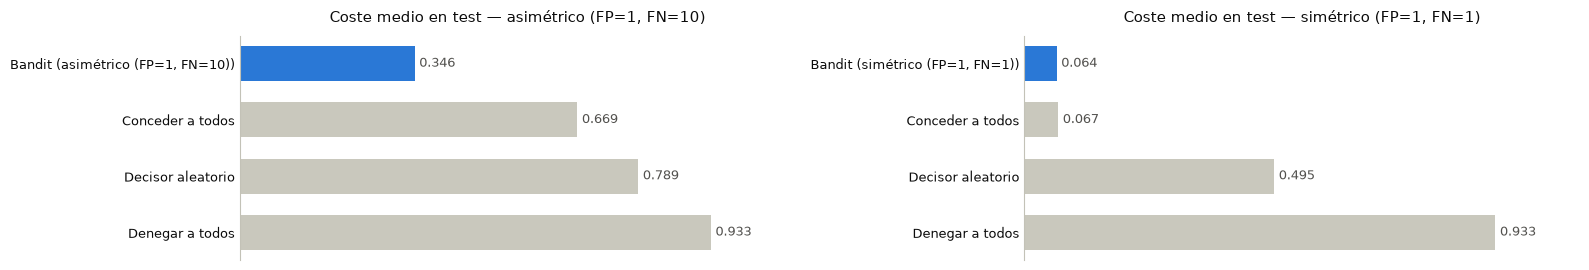

In [61]:
# Gráfico: coste medio en test por política, un panel por escenario (el bandit destacado)
fig, axes = plt.subplots(1, len(bandits), figsize=(8 * len(bandits), 2.8), squeeze=False)
for ax, (nombre, esc) in zip(axes[0], bandits.items()):
    M = esc.matriz_recompensa
    costes = {n_pol: coste_medio(acc, yte, M) for n_pol, acc in esc.politicas.items()}
    orden = sorted(costes, key=costes.get)  # menor coste arriba (mejor)
    valores = [costes[n_pol] for n_pol in orden]
    colores = ["#2a78d6" if n_pol.startswith("Bandit") else "#c9c8bd" for n_pol in orden]
    barras = ax.barh(orden, valores, color=colores, height=0.62)
    for barra, v in zip(barras, valores):
        ax.text(v + max(valores) * 0.01, barra.get_y() + barra.get_height() / 2,
                f"{v:.3f}", va="center", ha="left", fontsize=9, color="#52514e")
    ax.set_xlim(0, max(valores) * 1.18)
    ax.set_title(f"Coste medio en test — {nombre}", fontsize=11, color="#0b0b0b", pad=10)
    for s in ["top", "right", "bottom"]:
        ax.spines[s].set_visible(False)
    ax.spines["left"].set_color("#c3c2b7")
    ax.tick_params(axis="y", length=0, labelsize=9, colors="#0b0b0b")
    ax.set_xticks([])
    ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Explicabilidad con SHAP

SHAP (*SHapley Additive exPlanations*) reparte la salida del modelo entre las variables de entrada de forma **justa** (valores de Shapley, de teoría de juegos): para cada cliente descompone la predicción como un **valor base** (la media sobre una muestra de referencia) más la **contribución de cada variable**. Es **model-agnostic**: trata el bandit como una caja negra y solo necesita poder evaluarlo.

**¿Qué explicamos?** El bandit no devuelve una probabilidad, sino una decisión entre dos acciones, a cada una de las cuales asigna una puntuación (su refuerzo esperado). Explicamos el **margen a favor de denegar**:

$$ \text{score}(x) = \text{puntuación}(\text{denegar}) - \text{puntuación}(\text{conceder}), \qquad \textbf{denegar} \iff \text{score}(x) > 0 . $$

Con esta convención, una contribución SHAP **positiva** empuja al cliente hacia **denegar** (más riesgo) y una **negativa**, hacia **conceder**.

Veremos una vista **global** (qué variables mandan en toda la cartera y en qué dirección) y otra **local** (por qué se decidió sobre un cliente concreto).

In [62]:
# El bandit puntúa cada acción; explicamos el MARGEN a favor de denegar con SHAP.
# SHAP solo necesita esa función score y un "fondo" (baseline) representativo de la cartera.
fondo = shap.sample(X_train_scaled, 100, random_state=SEED)
X_shap = X_test_scaled.sample(500, random_state=SEED)  # misma muestra para comparar escenarios

for nombre, esc in bandits.items():
    explainer = shap.Explainer(esc.score_denegar, fondo)  # permutaciones: exacto para este modelo
    esc.shap_values = explainer(X_shap)
    print(f"[{nombre}] explicadas {X_shap.shape[0]} solicitudes | "
          f"valor base (score medio de la cartera): {esc.shap_values.base_values[0]:+.3f}")

[asimétrico (FP=1, FN=10)] explicadas 500 solicitudes | valor base (score medio de la cartera): -0.361
[simétrico (FP=1, FN=1)] explicadas 500 solicitudes | valor base (score medio de la cartera): -0.884


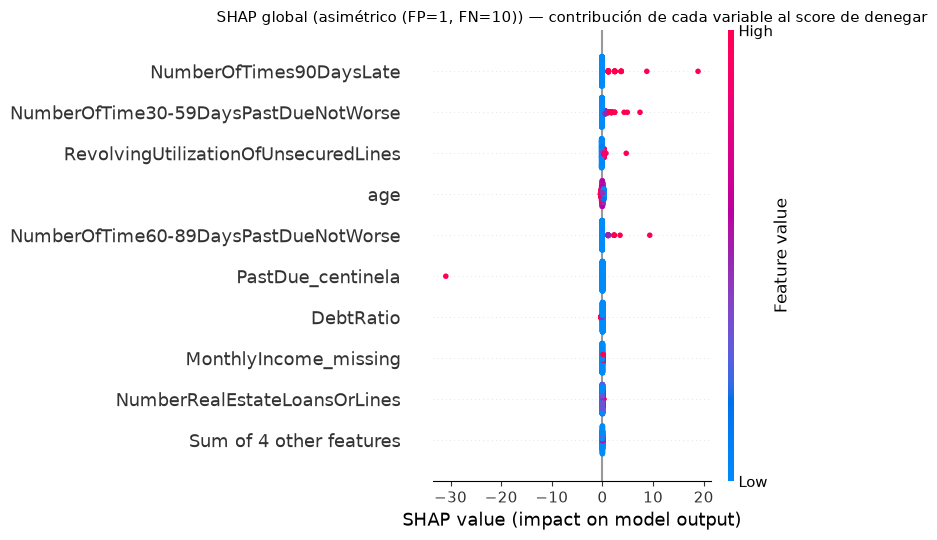

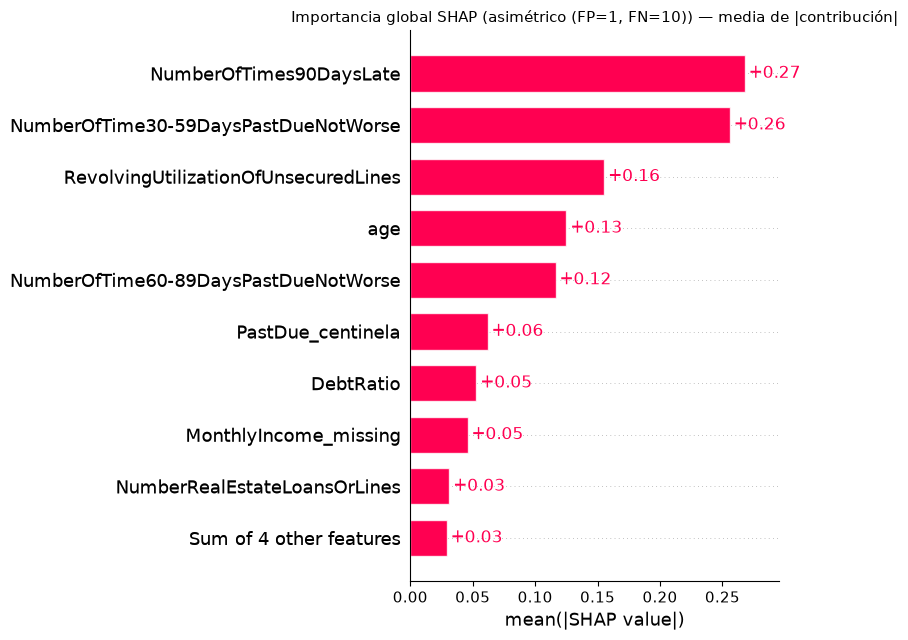

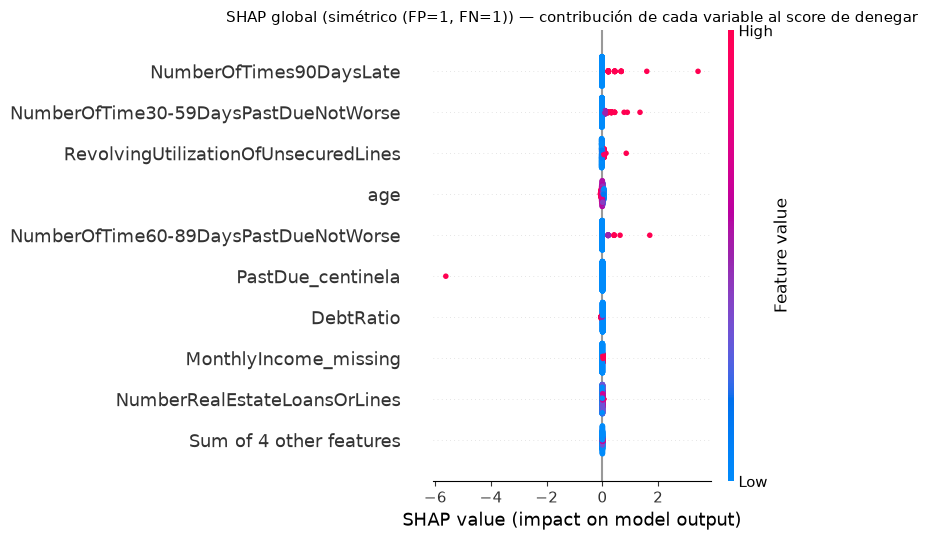

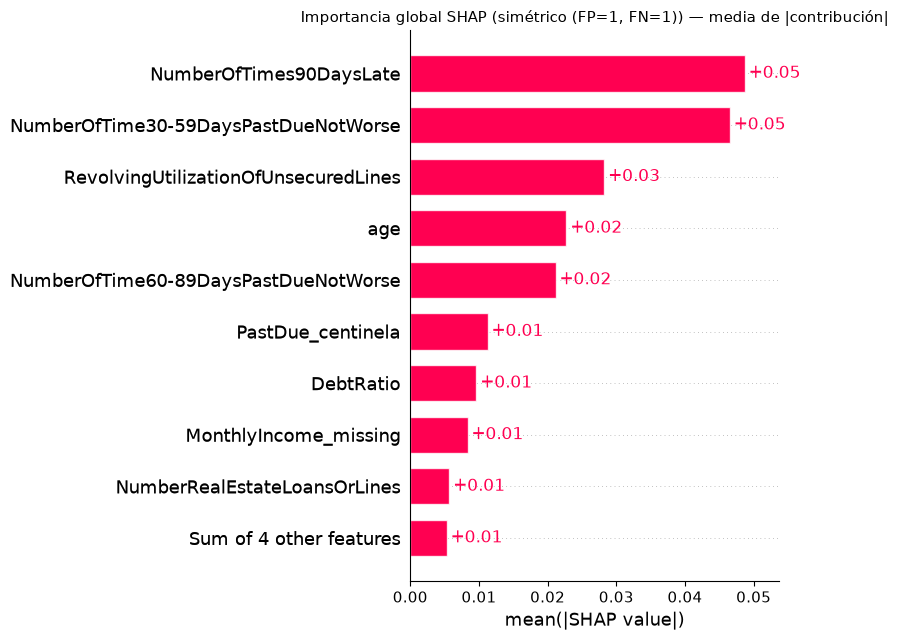

In [63]:
# Vista GLOBAL por escenario: beeswarm (contribución de cada variable al score de denegar)
# e importancia media (media de |SHAP| por variable).
for nombre, esc in bandits.items():
    shap.plots.beeswarm(esc.shap_values, show=False)
    plt.title(f"SHAP global ({nombre}) — contribución de cada variable al score de denegar", fontsize=11)
    plt.tight_layout()
    plt.show()

    shap.plots.bar(esc.shap_values, show=False)
    plt.title(f"Importancia global SHAP ({nombre}) — media de |contribución|", fontsize=11)
    plt.tight_layout()
    plt.show()

**Lectura global.** El *beeswarm* muestra que las variables que más pesan en la decisión son, por este orden, los **contadores de retraso en el pago** (`NumberOfTimes90DaysLate`, `NumberOfTime30-59DaysPastDueNotWorse`, `NumberOfTime60-89DaysPastDueNotWorse`), el flag `PastDue_centinela` y la **utilización de crédito** (`RevolvingUtilizationOfUnsecuredLines`). En todas ellas los **valores altos** (puntos rojos) tienen contribución SHAP **positiva**: empujan a **denegar**, como cabe esperar del riesgo de crédito. La `age` va en sentido contrario: a mayor edad, contribución negativa (hacia conceder).

Dos matices:

- Como el modelo trabaja con variables **estandarizadas**, un valor "alto" (rojo) significa *por encima de la media de la cartera*.
- `PastDue_centinela = 1` contribuye claramente a **denegar**, coherente con que esas solicitudes tenían un 53% de morosidad. SHAP reparte esa contribución cliente a cliente según el valor de cada variable, ofreciendo una importancia más matizada que una única cifra global por variable.

**Contraste simétrico vs. asimétrico.** El *orden* de importancia es casi idéntico en ambos escenarios —mandan los contadores de impago, la utilización de crédito y la edad—, pero la **magnitud se desploma** al igualar los costes: la importancia media total (suma de |SHAP| sobre todas las variables) pasa de **1,14** en el asimétrico a **0,21** en el simétrico, y el líder `NumberOfTimes90DaysLate` cae de **0,27** a **0,05**. Además, el **valor base** baja de **−0,36** a **−0,88**: con FN=1 toda la cartera parte mucho más metida en la zona de *conceder* (score ≪ 0), de modo que hace falta un empujón mucho mayor para cruzar a *denegar*. La lectura clave es que **no cambian ni los datos ni qué variables importan, sino cuánto pesa cada una**: al abaratar el falso negativo, el modelo apenas se atreve a denegar y todas las contribuciones se aplanan.

[asimétrico (FP=1, FN=10)] cliente DENEGADO (posición 306 de la muestra): score = +8.53


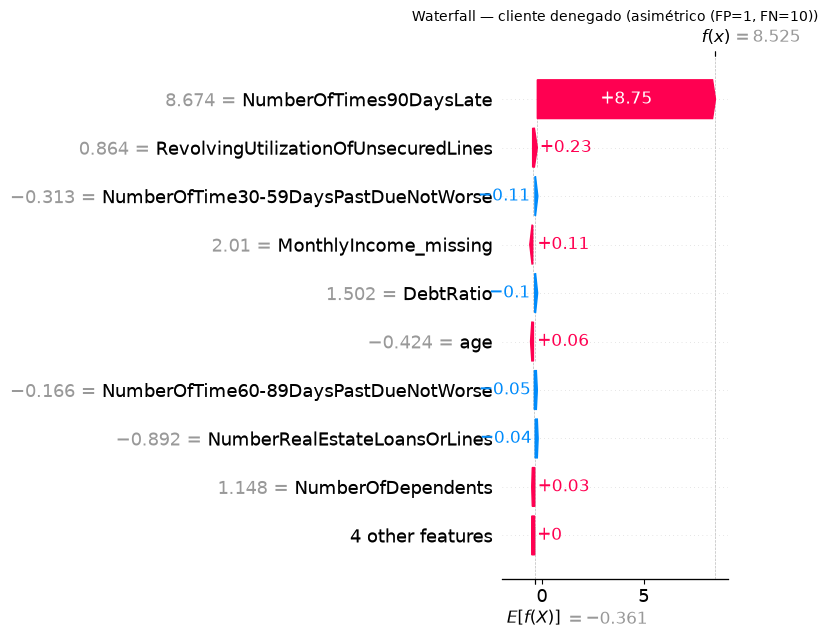

[asimétrico (FP=1, FN=10)] cliente CONCEDIDO (posición 278 de la muestra): score = -1.20


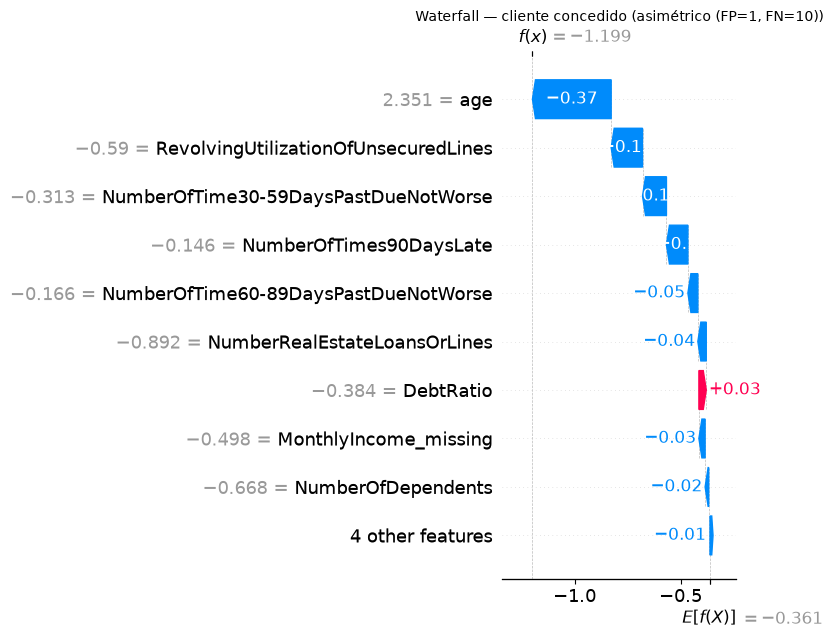

[simétrico (FP=1, FN=1)] cliente DENEGADO (posición 306 de la muestra): score = +0.73


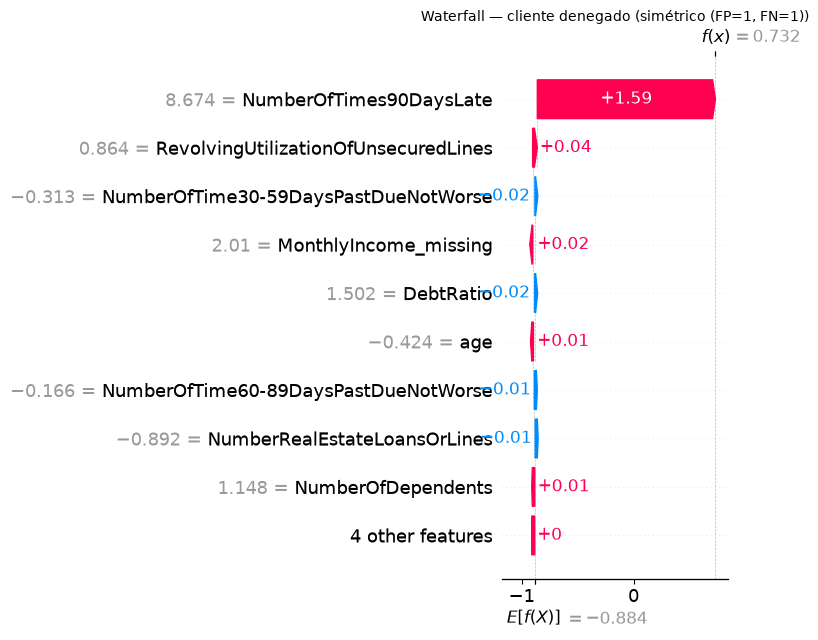

[simétrico (FP=1, FN=1)] cliente CONCEDIDO (posición 278 de la muestra): score = -1.04


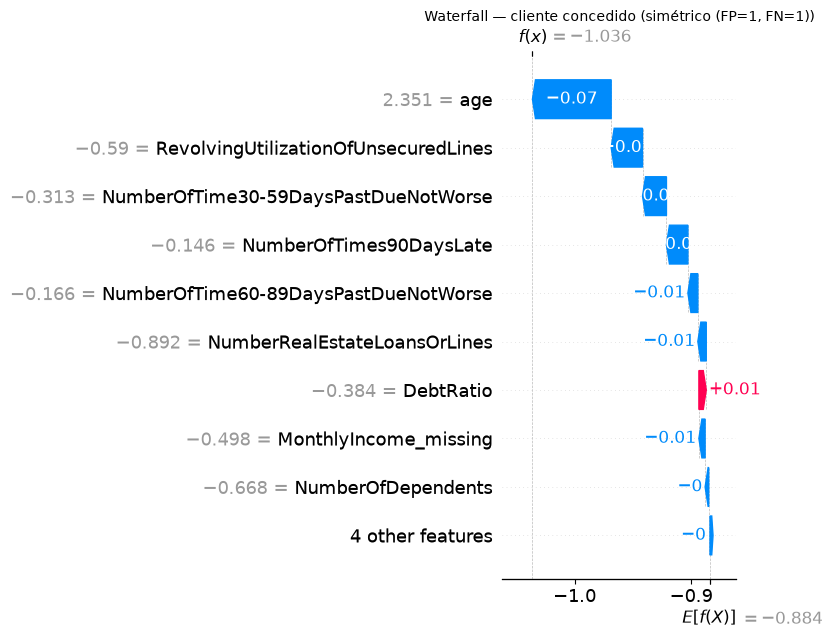

In [64]:
# Vista LOCAL por escenario: waterfall del cliente más claramente denegado y del más concedido.
for nombre, esc in bandits.items():
    scores = esc.score_denegar(X_shap.values)
    i_denegado = int(np.argmax(scores))   # score más alto -> claramente denegado
    i_concedido = int(np.argmin(scores))  # score más bajo -> claramente concedido

    print(f"[{nombre}] cliente DENEGADO (posición {i_denegado} de la muestra): score = {scores[i_denegado]:+.2f}")
    shap.plots.waterfall(esc.shap_values[i_denegado], show=False)
    plt.title(f"Waterfall — cliente denegado ({nombre})", fontsize=10)
    plt.tight_layout()
    plt.show()

    print(f"[{nombre}] cliente CONCEDIDO (posición {i_concedido} de la muestra): score = {scores[i_concedido]:+.2f}")
    shap.plots.waterfall(esc.shap_values[i_concedido], show=False)
    plt.title(f"Waterfall — cliente concedido ({nombre})", fontsize=10)
    plt.tight_layout()
    plt.show()

**Lectura local.** El *waterfall* parte del **valor base** (el score medio de la cartera) y va sumando y restando la contribución de cada variable hasta llegar al **score final** del cliente. En el cliente **denegado**, los contadores de impago y la utilización de crédito empujan con fuerza hacia la derecha (denegar); en el **concedido**, esas mismas variables, en valores bajos, tiran hacia la izquierda (conceder). Es la herramienta idónea para **justificar una decisión individual** ante el propio cliente o ante un regulador, un requisito habitual en credit scoring.

**Contraste simétrico vs. asimétrico.** Para el **mismo cliente** más claramente denegado de la muestra, el score final cae de **+8,53** (asimétrico) a **+0,73** (simétrico): en el escenario simétrico ni siquiera el caso más extremo se aleja de la frontera, así que los *waterfalls* quedan mucho más planos y **todas las denegaciones son fronterizas**. El cliente concedido, en cambio, apenas varía (**−1,20** vs **−1,04**): conceder es la decisión "por defecto" en ambos, pero el simétrico es mucho más reacio a denegar. Dicho de otro modo, la asimetría de coste no cambia *a quién* se ve como más arriesgado, sino **con cuánta rotundidad** se le deniega.

## Explicabilidad con un árbol surrogado

Un **modelo surrogado** es un modelo simple e interpretable —aquí, un **árbol de decisión**— entrenado para **imitar las decisiones del bandit**, no para predecir la morosidad real. Es su "gemelo caja blanca": si reproduce fielmente lo que hace el bandit, podemos leer sus reglas para entender la política global de un vistazo.

Claves del montaje:

- **El objetivo del árbol son las decisiones del bandit** (`conceder` / `denegar`), obtenidas con `model.predict`. No usamos la etiqueta real `SeriousDlqin2yrs`: queremos explicar el *modelo*, no los datos.
- **Entrenamos con las features SIN escalar.** Los árboles son invariantes a la escala, así que la fidelidad es idéntica, pero los umbrales quedan en **unidades reales e interpretables** (`NumberOfTimes90DaysLate <= 0.5`, `age <= 61.5`) en vez de en z-scores.
- **Fidelidad**: qué porcentaje de las decisiones del bandit reproduce el árbol. La medimos en **test** (out-of-sample) para no engañarnos con un ajuste optimista.

In [65]:
# Compromiso fidelidad / complejidad del árbol surrogado, por escenario
for nombre, esc in bandits.items():
    filas = []
    for profundidad in [2, 3, 4, 5]:
        arbol = DecisionTreeClassifier(max_depth=profundidad, random_state=SEED).fit(
            X_train_limpio, esc.acciones_train)
        filas.append({
            "profundidad": profundidad,
            "n_hojas": arbol.get_n_leaves(),
            "fidelidad_train": arbol.score(X_train_limpio, esc.acciones_train),
            "fidelidad_test": arbol.score(X_test_limpio, esc.acciones_test),
        })
    print(f"\nESCENARIO {nombre}:")
    print(pd.DataFrame(filas).set_index("profundidad").round(4))


ESCENARIO asimétrico (FP=1, FN=10):
             n_hojas  fidelidad_train  fidelidad_test
profundidad                                          
2                  4           0.9444          0.9450
3                  7           0.9727          0.9726
4                 12           0.9836          0.9834
5                 21           0.9873          0.9868

ESCENARIO simétrico (FP=1, FN=1):
             n_hojas  fidelidad_train  fidelidad_test
profundidad                                          
2                  4           0.9920          0.9920
3                  8           0.9954          0.9952
4                 16           0.9963          0.9963
5                 29           0.9977          0.9976


[asimétrico (FP=1, FN=10)] fidelidad en test: 97.26%  (7 hojas)
Concordancia de decisiones en test [fila = bandit, col = árbol]:
                  árbol: conceder  árbol: denegar
bandit: conceder            17199             123
bandit: denegar               452            3226


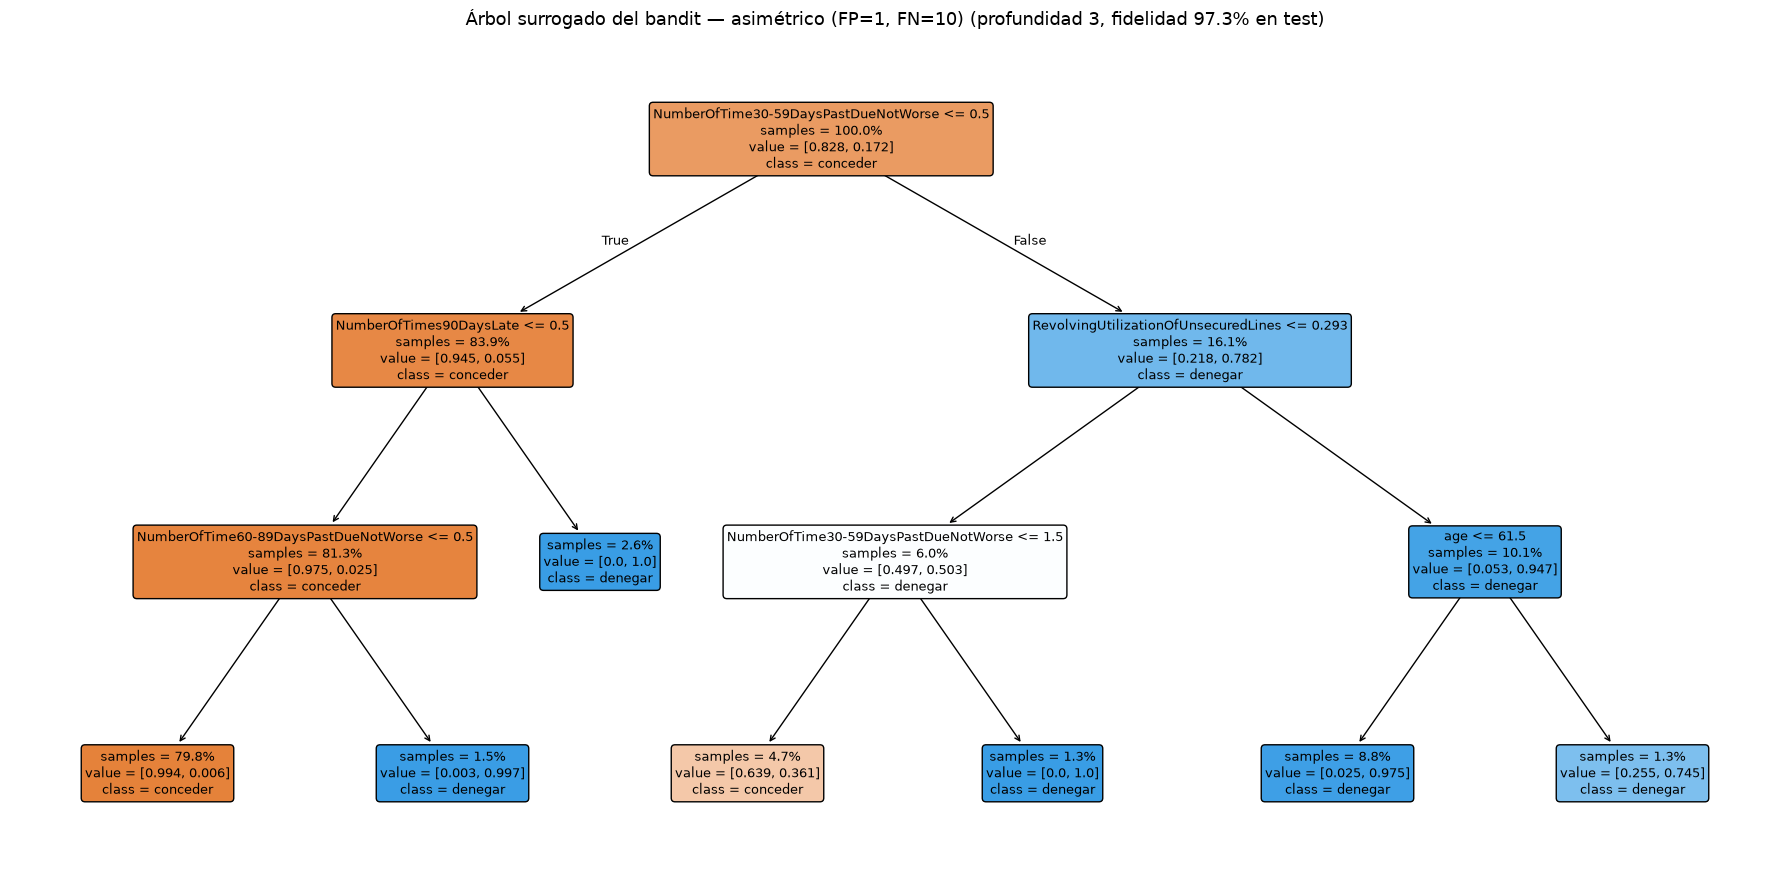

[simétrico (FP=1, FN=1)] fidelidad en test: 99.52%  (8 hojas)
Concordancia de decisiones en test [fila = bandit, col = árbol]:
                  árbol: conceder  árbol: denegar
bandit: conceder            20681              27
bandit: denegar                73             219


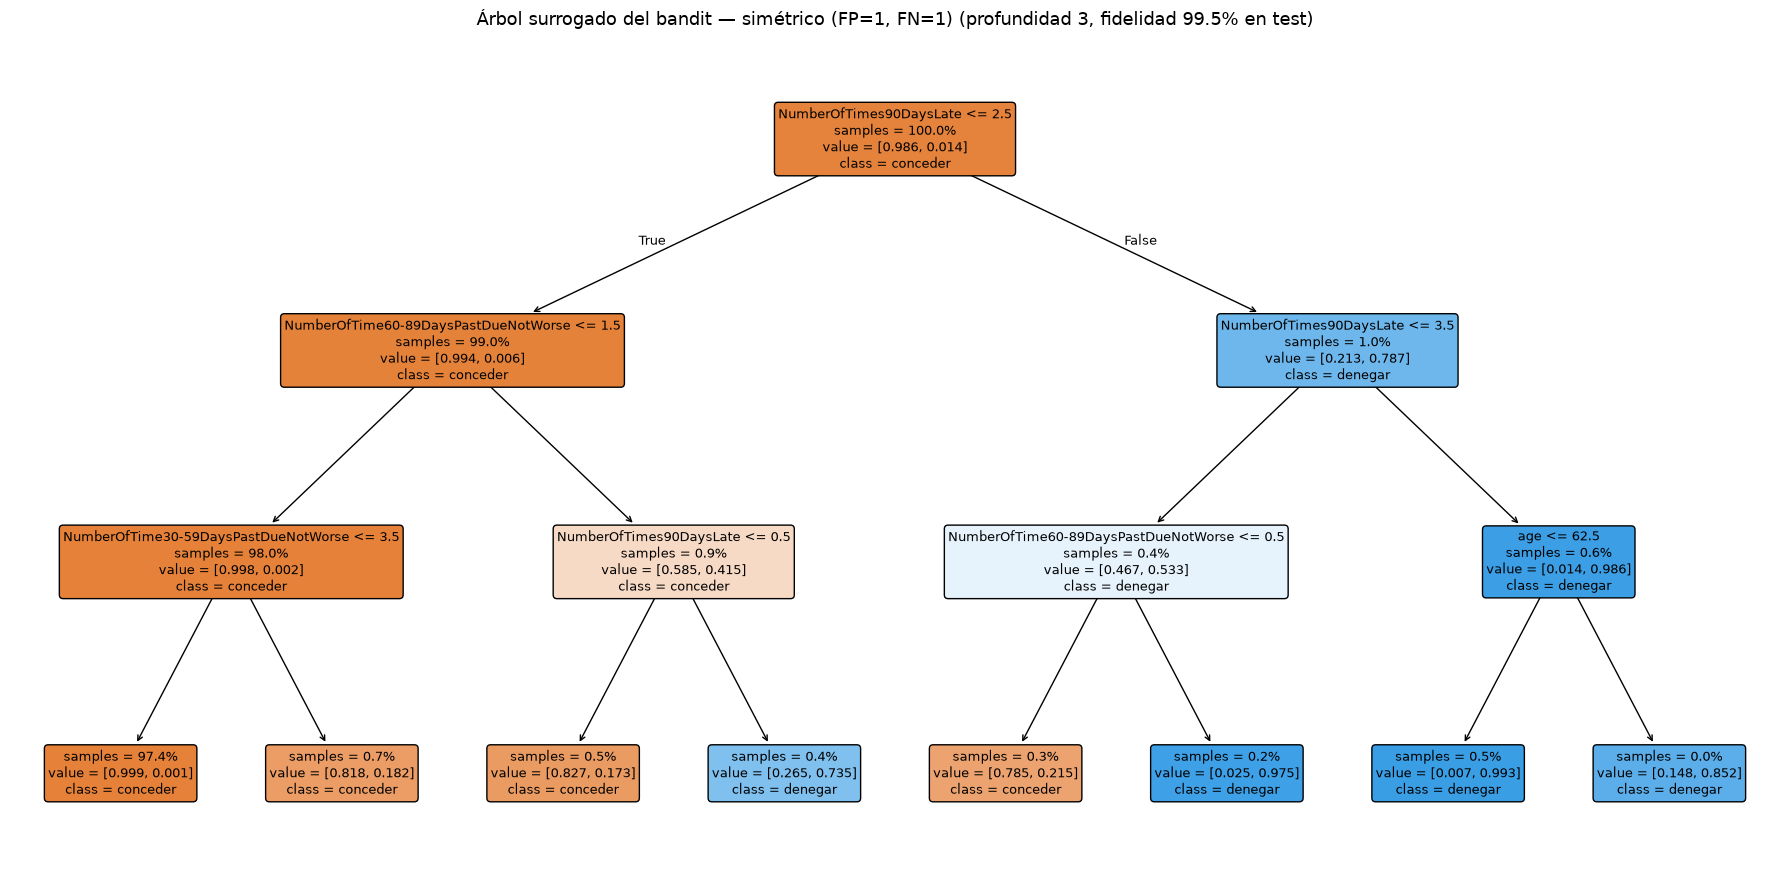

In [66]:
# Árbol surrogado final (profundidad 3) por escenario
PROFUNDIDAD = 3
for nombre, esc in bandits.items():
    esc.surrogado = DecisionTreeClassifier(max_depth=PROFUNDIDAD, random_state=SEED).fit(
        X_train_limpio, esc.acciones_train)
    fidelidad = esc.surrogado.score(X_test_limpio, esc.acciones_test)
    print(f"[{nombre}] fidelidad en test: {fidelidad:.2%}  ({esc.surrogado.get_n_leaves()} hojas)")

    cm = confusion_matrix(esc.acciones_test, esc.surrogado.predict(X_test_limpio), labels=[0, 1])
    print("Concordancia de decisiones en test [fila = bandit, col = árbol]:")
    print(pd.DataFrame(cm, index=["bandit: conceder", "bandit: denegar"],
                       columns=["árbol: conceder", "árbol: denegar"]))

    fig, ax = plt.subplots(figsize=(18, 9))
    plot_tree(esc.surrogado, feature_names=list(X_train_limpio.columns),
              class_names=["conceder", "denegar"], filled=True, rounded=True,
              impurity=False, proportion=True, fontsize=9, ax=ax)
    ax.set_title(f"Árbol surrogado del bandit — {nombre} "
                 f"(profundidad {PROFUNDIDAD}, fidelidad {fidelidad:.1%} en test)", fontsize=13)
    plt.tight_layout()
    plt.show()

**Lectura del árbol.** El surrogado reproduce el **~97% de las decisiones** del bandit con reglas muy simples, y coincide con lo que vimos en SHAP: la política está dominada por los **contadores de retraso en el pago**. Leyendo las ramas:

- Si el cliente **no tiene ningún retraso reciente** (30-59, 60-89 y 90 días todos en 0) → **conceder**.
- **Cualquier** impago empuja a **denegar**: un solo retraso de 90 días lo deniega casi de forma automática, e igual ocurre con los de 60-89 días.
- Cuando solo hay retrasos leves de 30-59 días, la decisión se afina con la **utilización de crédito** (`RevolvingUtilizationOfUnsecuredLines`) y, marginalmente, la **edad**.

Es una **política legible en una sola página**, ideal para auditar o comunicar el modelo.

**Caveats honestos:**

- El árbol es una **aproximación**: falla en ~3% de los casos, porque las fronteras del bandit no son escalones perfectos. Subir la profundidad mejora la fidelidad a costa de legibilidad (ver la tabla anterior).
- Como todo surrogado global, **suaviza** matices: dos clientes en la misma hoja pueden tener scores del bandit distintos. Para justificar un caso individual, el *waterfall* de SHAP es más preciso.
- El árbol explica **la política del bandit**, que a su vez depende de los **costes elegidos** (FP=1, FN=10): con otros costes cambiaría el umbral y el árbol sería distinto.

**Contraste simétrico vs. asimétrico.** El árbol del escenario **simétrico** logra incluso **más fidelidad** que el asimétrico (**99,5%** vs **97,3%** a profundidad 3), pero por un motivo revelador: su política es **casi constante** —deniega solo al **1,4%** del test frente al **17,5%** del asimétrico—, así que imitarla es trivial (casi siempre "conceder"). Más fidelidad **no** significa mejor política ni explicación más rica: significa que hay poquísimo que explicar. En el asimétrico, el árbol debe capturar una frontera real (deniega a 1 de cada 6 clientes) y por eso su ~3% de error es más informativo. Son el mismo árbol y las mismas variables dominantes (los contadores de impago), pero con un **umbral de denegación mucho más exigente** en el simétrico: la política sigue siendo legible, solo que casi siempre concede.

## Explicabilidad con contrafactuals: análisis de *recourse*

Un **contrafactual** responde a la pregunta: *"¿cuál es el cambio mínimo en las variables de un cliente que invierte la decisión del bandit?"*. Nos centramos en el **recourse**: para clientes a los que el bandit **deniega** el crédito, buscamos qué tendrían que cambiar para que **se lo concediera**. Es la explicación local más accionable y una pieza habitual en credit scoring ("¿qué necesito para que me aprueben?").

Elegiremos clientes denegados de **ambas clases reales** para contrastar:

- **FP** — cliente **sano** (`y=0`) rechazado: un buen cliente mal clasificado. Su recourse suele ser *fácil* (la denegación es frágil).
- **TP** — cliente **moroso** (`y=1`) rechazado: un cliente genuinamente arriesgado. Su recourse debería ser *más costoso* (más cambios), porque el modelo está más seguro.

**Cómo lo buscamos (transparente, sin librerías).** Perturbamos solo variables **accionables** en su dirección de mejora y buscamos numéricamente el cambio mínimo que da la vuelta a la decisión, respetando:

- **Inmutabilidad**: no tocamos `age` ni los flags (`MonthlyIncome_missing`, `NumberOfDependents_missing`, `PastDue_centinela`).
- **Dirección realista**: los contadores de impago, la utilización de crédito y el `DebtRatio` solo pueden **mejorar bajando**; `MonthlyIncome`, subiendo.
- **Plausibilidad**: contadores enteros ≥ 0, ingresos acotados a un máximo razonable (p95 de train).
- **Escalado**: el cliente modificado se re-escala con el mismo `StandardScaler` antes de consultar al bandit.

Damos dos vistas: el recourse de **una sola variable** (recetas alternativas) y el recourse **combinado** (cambio conjunto mínimo) cuando ninguna variable basta por sí sola.

In [67]:
class BuscadorRecourse:
    """Busca el cambio mínimo en variables ACCIONABLES que hace que el bandit pase de
    DENEGAR (1) a CONCEDER (0) a un cliente (recourse). Trabaja en unidades reales y
    re-escala internamente con el mismo StandardScaler para consultar al modelo.
    """

    def __init__(self, model, scaler, columnas, accionables):
        # accionables: lista de tuplas (nombre, direccion, minimo, maximo, es_entero)
        #   direccion = -1 (mejora al BAJAR: impagos, deuda) | +1 (mejora al SUBIR: ingresos)
        self.model = model
        self.scaler = scaler
        self.columnas = list(columnas)
        self.idx = {c: i for i, c in enumerate(self.columnas)}
        self.accionables = accionables

    # --- consultas al modelo (escala el vector real antes de preguntar) ---
    def _escalar(self, x):
        return self.scaler.transform(pd.DataFrame(x.reshape(1, -1), columns=self.columnas))

    def _accion(self, x):
        return int(self.model.predict(self._escalar(x), thompson=False)[0])

    def _score_denegar(self, x):
        ev = self.model.expected_values(self._escalar(x))  # (2, 1): fila 0 conceder, 1 denegar
        return float((ev[1] - ev[0]).item())

    # --- utilidades sobre una variable accionable ---
    def _mejor_valor(self, spec):
        _, direccion, minimo, maximo, _ = spec
        return minimo if direccion < 0 else maximo

    def _mejorable(self, spec, x):
        nombre, direccion, *_ = spec
        v0 = x[self.idx[nombre]]
        mejor = self._mejor_valor(spec)
        return mejor is not None and ((direccion < 0 and mejor < v0) or (direccion > 0 and mejor > v0))

    def _minimizar(self, x, v0, spec):
        """Búsqueda binaria del cambio mínimo en `spec` (resto fijo) que sigue concediendo."""
        nombre, direccion, minimo, maximo, entero = spec
        idx = self.idx[nombre]
        cur = x[idx]
        lo, hi = (cur, v0) if direccion < 0 else (v0, cur)
        for _ in range(40):
            mid = (lo + hi) / 2
            x[idx] = mid
            concede = self._accion(x) == 0
            if concede == (direccion < 0):
                lo = mid
            else:
                hi = mid
        umbral = lo if direccion < 0 else hi
        valor = (int(np.floor(umbral)) if direccion < 0 else int(np.ceil(umbral))) if entero else round(umbral, 3)
        x[idx] = valor
        if self._accion(x) != 0:  # el redondeo se pasó de la frontera: volvemos al valor seguro
            x[idx] = cur
        return x[idx]

    # --- API pública ---
    def recourse_una_variable(self, cliente):
        """Para cada variable accionable, el cambio individual mínimo que concede (si existe)."""
        base = np.asarray(cliente, dtype=float)
        filas = []
        for spec in self.accionables:
            nombre = spec[0]
            v0 = base[self.idx[nombre]]
            if not self._mejorable(spec, base):
                continue
            x = base.copy()
            x[self.idx[nombre]] = self._mejor_valor(spec)
            if self._accion(x) != 0:      # ni con el cambio máximo se concede
                continue
            nuevo = self._minimizar(x, v0, spec)
            filas.append({"variable": nombre, "actual": round(v0, 3),
                          "nuevo": nuevo, "cambio": round(nuevo - v0, 3)})
        return pd.DataFrame(filas)

    def recourse_combinado(self, cliente):
        """Recourse conjunto mínimo (greedy): mejora la variable de mayor efecto hasta
        conceder y luego minimiza la última variable tocada. Devuelve None si es inalcanzable."""
        base = np.asarray(cliente, dtype=float)
        x = base.copy()
        restantes = list(self.accionables)
        ultima = None
        for _ in range(len(self.accionables)):
            if self._accion(x) == 0:
                break
            candidatas = [s for s in restantes if self._mejorable(s, x)]
            if not candidatas:
                break
            # la que más reduce el score de denegar al mejorarla del todo
            def reduccion(s):
                xx = x.copy()
                xx[self.idx[s[0]]] = self._mejor_valor(s)
                return self._score_denegar(x) - self._score_denegar(xx)
            ultima = max(candidatas, key=reduccion)
            x[self.idx[ultima[0]]] = self._mejor_valor(ultima)
            restantes.remove(ultima)
        if self._accion(x) != 0:
            return None
        if ultima is not None:
            self._minimizar(x, base[self.idx[ultima[0]]], ultima)
        filas = [{"variable": c, "actual": round(base[i], 3), "nuevo": round(x[i], 3),
                  "cambio": round(x[i] - base[i], 3)}
                 for i, c in enumerate(self.columnas) if abs(x[i] - base[i]) > 1e-9]
        return pd.DataFrame(filas)

In [68]:
# Variables accionables: (nombre, dirección, mínimo, máximo, entero) — idénticas para todos los escenarios
#   dirección: -1 = mejora al BAJAR (impagos, utilización, deuda); +1 = mejora al SUBIR (ingresos)
INGRESO_MAX = float(X_train_limpio["MonthlyIncome"].quantile(0.95))
accionables = [
    ("NumberOfTimes90DaysLate", -1, 0, None, True),
    ("NumberOfTime60-89DaysPastDueNotWorse", -1, 0, None, True),
    ("NumberOfTime30-59DaysPastDueNotWorse", -1, 0, None, True),
    ("RevolvingUtilizationOfUnsecuredLines", -1, 0.0, None, False),
    ("DebtRatio", -1, 0.0, None, False),
    ("MonthlyIncome", +1, None, INGRESO_MAX, False),
]

for nombre, esc in bandits.items():
    print("#" * 78)
    print(f"ESCENARIO {nombre}  (deniega {esc.acciones_test.mean():.1%} del test)")
    buscador = BuscadorRecourse(esc.model, scaler, X_train_limpio.columns, accionables)

    denegados = esc.acciones_test == 1
    idx_fp = np.where(denegados & (y_test.values == 0))[0]  # sano rechazado (falso positivo)
    idx_tp = np.where(denegados & (y_test.values == 1))[0]  # moroso rechazado (verdadero positivo)

    casos = []
    if len(idx_fp):
        casos.append(("FP — cliente SANO rechazado (y=0)", idx_fp[0]))
    if len(idx_tp):
        casos.append(("TP — cliente MOROSO rechazado (y=1)", idx_tp[0]))
    if not casos:
        print("   (este escenario no deniega a ningún cliente en test: no hay recourse que mostrar)\n")
        continue

    for etiqueta, i in casos:
        cliente = X_test_limpio.iloc[i]
        print("=" * 72)
        print(f"{etiqueta}  |  decisión del bandit: DENEGAR")
        print("\n· Recourse con UNA sola variable (recetas alternativas):")
        una = buscador.recourse_una_variable(cliente)
        print(una.to_string(index=False) if len(una) else "   (ninguna variable individual basta para conceder)")
        print("\n· Recourse COMBINADO (cambio conjunto mínimo):")
        comb = buscador.recourse_combinado(cliente)
        print(comb.to_string(index=False) if comb is not None else "   (inalcanzable con las variables accionables)")
        print()

##############################################################################
ESCENARIO asimétrico (FP=1, FN=10)  (deniega 17.5% del test)
FP — cliente SANO rechazado (y=0)  |  decisión del bandit: DENEGAR

· Recourse con UNA sola variable (recetas alternativas):
                            variable  actual  nuevo  cambio
NumberOfTime60-89DaysPastDueNotWorse     1.0    0.0    -1.0

· Recourse COMBINADO (cambio conjunto mínimo):
                            variable  actual  nuevo  cambio
NumberOfTime60-89DaysPastDueNotWorse     1.0    0.0    -1.0

TP — cliente MOROSO rechazado (y=1)  |  decisión del bandit: DENEGAR

· Recourse con UNA sola variable (recetas alternativas):
   (ninguna variable individual basta para conceder)

· Recourse COMBINADO (cambio conjunto mínimo):
                            variable  actual  nuevo  cambio
NumberOfTime30-59DaysPastDueNotWorse     1.0    0.0    -1.0
             NumberOfTimes90DaysLate     1.0    0.0    -1.0

#####################################

**Lectura de los contrafactuals.**

- **Cliente sano rechazado (FP):** basta **una sola mejora** (eliminar un retraso de pago) para que el bandit lo conceda. La denegación es *frágil*: coherente con que era un buen cliente mal clasificado, muy cerca de la frontera de decisión.
- **Cliente moroso rechazado (TP):** **ninguna variable por sí sola** consigue el recourse; hacen falta **varios cambios simultáneos**. El modelo lo tiene "profundamente" en la zona de denegar, lo que es razonable en un cliente genuinamente arriesgado.

La propiedad interesante es que **el esfuerzo del recourse escala con el riesgo que percibe el modelo**: cuanto más seguro está de denegar, más costoso es darle la vuelta. Es una forma muy intuitiva de comunicar la confianza de la decisión.

**Caveats honestos:**

- El recourse describe qué cambia **la decisión del modelo**, no la solvencia real. En el caso TP, el cliente sigue siendo un futuro moroso: conseguir el crédito modificando esas variables no lo hace menos arriesgado, solo refleja las features que el modelo observa.
- Tratamos las variables como **independientes**, pero no lo son del todo: `DebtRatio = deuda / ingreso`, así que subir el ingreso también debería bajar el `DebtRatio`. Es una simplificación; un recourse "causal" acoplaría esos cambios.
- Como SHAP y el árbol, el recourse explica **esta** política, que depende de los costes elegidos (FP=1, FN=10): con otros costes, la frontera se movería y el recourse cambiaría.

**Contraste simétrico vs. asimétrico.** Es aquí donde mejor se ve el efecto del coste. En el **asimétrico**, el moroso rechazado (TP) está *profundamente* en zona de denegar (score **+8,5**): ninguna variable por sí sola lo salva y hacen falta **varios cambios simultáneos**. En el **simétrico**, como el modelo apenas deniega, **todas** sus denegaciones son fronterizas (score ≤ **+0,7**), de modo que incluso el moroso rechazado recupera el crédito con **un único cambio** (`NumberOfTimes90DaysLate` de 3 a 2). Con costes simétricos, por tanto, el recourse es **uniformemente fácil** —el modelo nunca está muy seguro de denegar—, mientras que con FN=10 el esfuerzo del recourse **escala con el riesgo**: distingue al buen cliente mal clasificado (recourse trivial) del moroso genuino (recourse costoso). El escenario asimétrico es el que produce explicaciones contrafactuales más *discriminativas* y, por eso mismo, más útiles para comunicar la confianza de la decisión.